# Analysis of 10k windows at PASes

A rerun of the same analysis previously performed on TSSes, for PASes. We were able to previously show nucleosome near PASes differentially changed when separated by H3K56 acetylation level. This analysis may address this, otherwise, we may need to plan out a procedure to find this result again.

Clustered Nucleosome occupancy changes during S/G2/M to identify possible link between expression level and nucleosome dynamics due to replication effects.

### Procedure:
1. Identify highest and lowest expressed genes
2. Collect the chromatin data at TSSes and gene body nucleosome occupancy
3. Cluster on nucleosome occupancy changes per gene
4. Show the relationship between nucleosome occupancy changes with H3K56 acetylation and expression level
5. Perform gene ontology on clusters



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

outdir = "output/deconvolved_genome_g0066_offset1_10k_10x10_2024_10_11/"
analysis = GenomeDeconvolutionAnalysis(outdir)


In [3]:
from src.geneset import get_deconvolved_geneset
genes = get_deconvolved_geneset()

In [4]:
from src.reference_data import load_h3k56ac_marks

nuc_h3k56ac_table = load_h3k56ac_marks()
genes_h3k56ac = nuc_h3k56ac_table.loc[~nuc_h3k56ac_table.acc.isna()]
genes_h3k56ac = genes_h3k56ac[['H3K56ac', 'acc']].groupby('acc').mean()
genes_h3k56ac = genes_h3k56ac.join(genes[['chr', 'strand', 'TSS', 'PAS']], how='inner')
genes_h3k56ac = genes_h3k56ac.rename(columns={'H3K56ac': 'mean_acetylation'})
genes_h3k56ac.head()

,mean_acetylation,chr,strand,TSS,PAS
YAL001C,-0.367917,1,-,151205,147540
YAL002W,-0.117391,1,+,143552,147566
YAL003W,0.106667,1,+,142154,143369
YAL005C,0.101429,1,-,141494,139358
YAL007C,0.150000,1,-,138421,137523


In [5]:
# Compute box plot information for the acetylation values for each 
# gene's nucleosome H3K56 acetylation.

h3k56_steady_state_acetylation = load_h3k56ac_marks(full=False)
h3k56ac_qs = h3k56_steady_state_acetylation[['H3K56ac', 'acc']].groupby('acc')\
    .quantile(q=[0.25, 0.5, 0.75]).unstack()
h3k56ac_qs.columns = h3k56ac_qs.columns.droplevel(0)
h3k56ac_qs = h3k56ac_qs.join(genes[['chr', 'strand', 'TSS', 'PAS']], how='inner')
h3k56ac_qs.head()

,0.25,0.5,0.75,chr,strand,TSS,PAS
YAL001C,-0.445,-0.310,-0.205,1,-,151205,147540
YAL002W,-0.415,-0.140,0.110,1,+,143552,147566
YAL003W,-0.190,-0.090,0.305,1,+,142154,143369
YAL005C,0.005,0.070,0.155,1,-,141494,139358
YAL007C,0.075,0.165,0.175,1,-,138421,137523


In [6]:
from src.gene_clustering import GeneClustering
outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'
gene_clustering = GeneClustering(outdir)


In [7]:
genes_replication = pd.read_csv('data/replication_timing/yl_2019/genes_replication_timing_shared.csv').set_index('orf_name')
genes_replication = genes_replication.sort_values('replication_time')

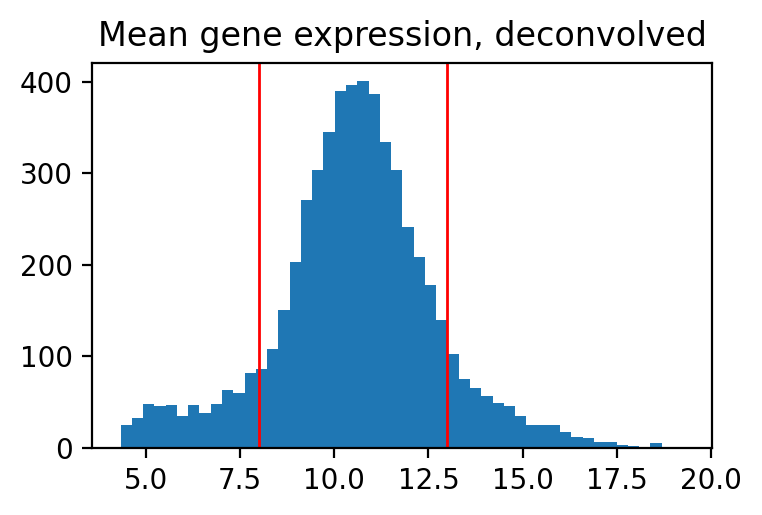

In [8]:
t_indices = gene_clustering.config.get_Hpositions_for_branch('t')
deconvolved_gene_expression_t = gene_clustering.gene_expression[t_indices]
plt.figure(figsize=(4, 2.5))
plt.hist(deconvolved_gene_expression_t.mean(axis=1), bins=50)
plt.title("Mean gene expression, deconvolved")
cutoffs = 8, 13
for cutoff in cutoffs:
    plt.axvline(cutoff, c='red', lw=1)

In [9]:
low_tx_genes = deconvolved_gene_expression_t[
    deconvolved_gene_expression_t.max(axis=1) < cutoffs[0]]
high_tx_genes = deconvolved_gene_expression_t[
    deconvolved_gene_expression_t.min(axis=1) > cutoffs[1]]
print(f"Low expressed genes: {len(low_tx_genes)}")
print(f"High expressed genes: {len(high_tx_genes)}")

Low expressed genes: 494
High expressed genes: 445


In [10]:
mean_low_tx_genes, low_tx_gb_nuc_occ = \
    analysis.load_stacked_mnase_data_for_genes(low_tx_genes, padding=1000,
                                              center_mode='PAS_nuc', 
                                               compute_gb_occ=True)

Failed to load 7 files


In [11]:
mean_high_tx_genes, high_tx_gb_nuc_occ = analysis.load_stacked_mnase_data_for_genes(
    high_tx_genes, padding=1000, center_mode='PAS_nuc', compute_gb_occ=True)


In [12]:
normalized_low_tx_gb = (low_tx_gb_nuc_occ - \
    low_tx_gb_nuc_occ.mean(axis=1).values.reshape((-1,1)))/\
    low_tx_gb_nuc_occ.std(axis=1).values.reshape((-1,1))

normalized_high_tx_gb = (high_tx_gb_nuc_occ - \
    high_tx_gb_nuc_occ.mean(axis=1).values.reshape((-1,1)))/\
    high_tx_gb_nuc_occ.std(axis=1).values.reshape((-1,1))


Text(0.5, 0.98, 'Gene body nucleosome occupancy')

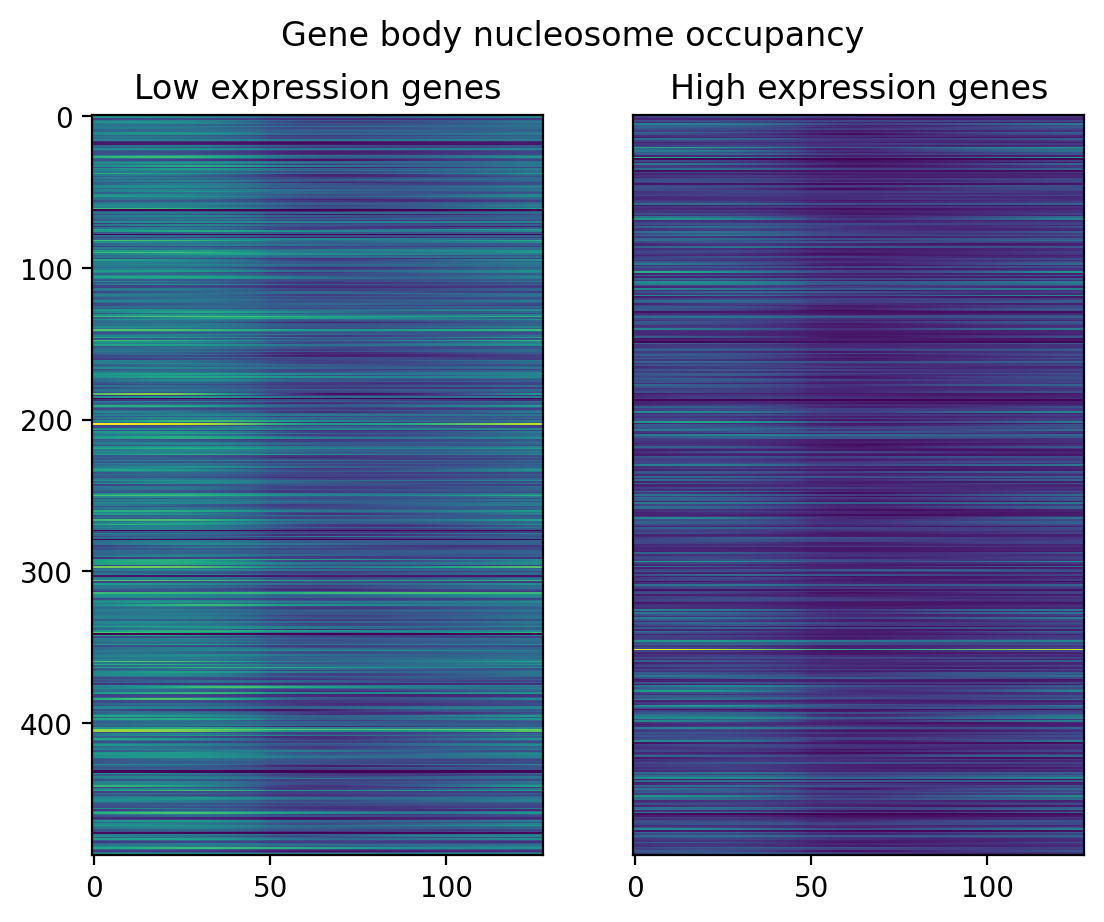

In [13]:
plt.subplot(1, 2, 1)
plt.imshow(low_tx_gb_nuc_occ.dropna().astype(float)[t_indices],
                     interpolation='none', aspect='auto')
plt.title("Low expression genes")

plt.subplot(1, 2, 2)
plt.imshow(high_tx_gb_nuc_occ.dropna().astype(float)[t_indices], aspect='auto', 
           interpolation='none')
plt.yticks([])
plt.title("High expression genes")

plt.suptitle("Gene body nucleosome occupancy")

In [14]:
sorted_low_tx_repl = genes_replication.loc[normalized_low_tx_gb.index]\
    .sort_values('replication_time').index
sorted_high_tx_repl = genes_replication.loc[normalized_high_tx_gb.index]\
    .sort_values('replication_time').index

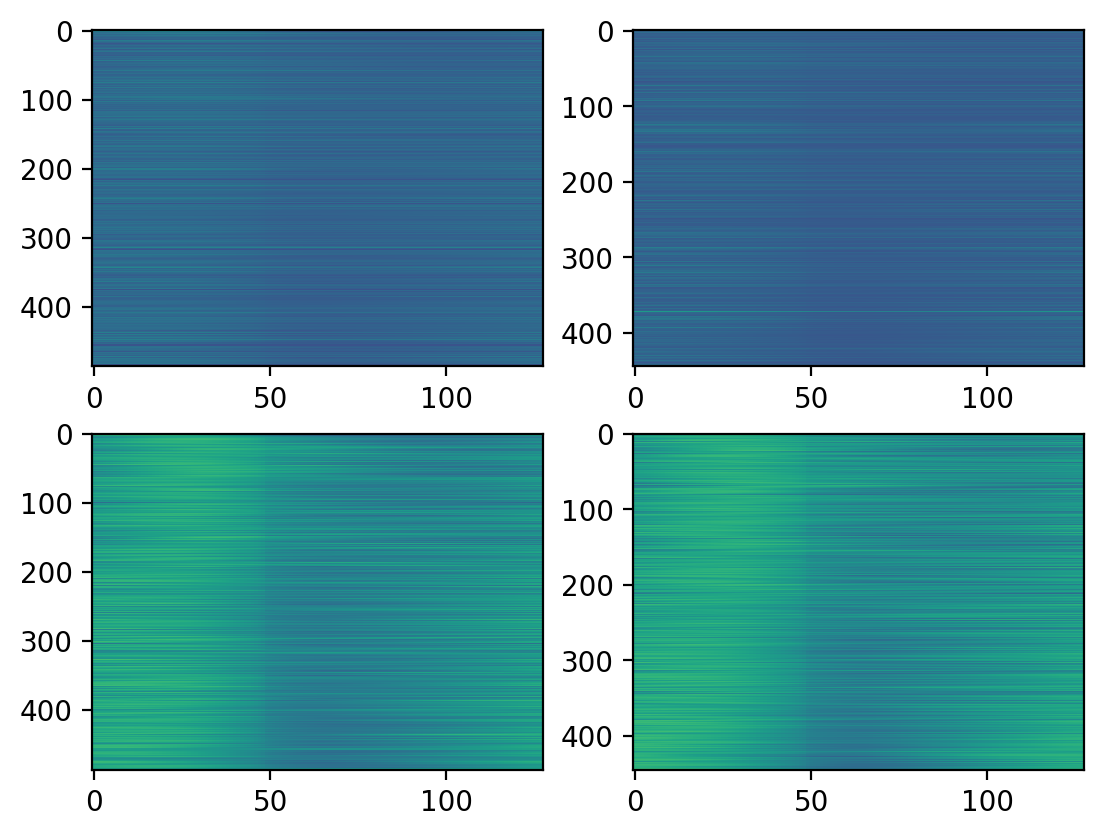

In [15]:
plt.subplot(2, 2, 1)
plt.imshow(low_tx_gb_nuc_occ.loc[sorted_low_tx_repl].dropna().astype(float)[t_indices],
                     interpolation='none', aspect='auto', vmin=0, vmax=5000)
plt.subplot(2, 2, 2)
plt.imshow(high_tx_gb_nuc_occ.loc[sorted_high_tx_repl].dropna().astype(float)[t_indices], 
    aspect='auto', interpolation='none', vmin=0, vmax=5000)

plt.subplot(2, 2, 3)
plt.imshow(normalized_low_tx_gb.loc[sorted_low_tx_repl].dropna().astype(float)[t_indices],
                     interpolation='none', aspect='auto', vmin=-5, vmax=5)
plt.subplot(2, 2, 4)
plt.imshow(normalized_high_tx_gb.loc[sorted_high_tx_repl].dropna().astype(float)[t_indices], 
    aspect='auto', interpolation='none', vmin=-5, vmax=5)


In [16]:
from sklearn.cluster import KMeans
n_clusters = 9
def cluster_gb_data(normalized_gb,_gb_nuc_occ):
    kmeans = KMeans(n_clusters=n_clusters, random_state=13, n_init="auto").fit(
       _gb_nuc_occ.dropna()[t_indices])

    clustered_gb =_gb_nuc_occ.dropna().copy()
    clustered_gb['cluster'] = kmeans.labels_+1
    clustered_gb = clustered_gb.reset_index().set_index(['cluster', 'orf_name'])
    clustered_gb = clustered_gb.sort_index()

    plt.subplot(1, 2, 1)
    plt.imshow(clustered_gb.astype(float)[t_indices],
                         interpolation='none', aspect='auto', vmin=0, vmax=5000)
    plt.title("Raw")
    plt.subplot(1, 2, 2)
    plt.imshow(normalized_gb.loc[clustered_gb.reset_index().orf_name][t_indices]\
        .astype(float), aspect='auto', interpolation='none', vmin=-2, vmax=2)
    plt.title("Normalized")
    
    return clustered_gb


Text(0.5, 0.98, 'Lowly expressed genes, n=494')

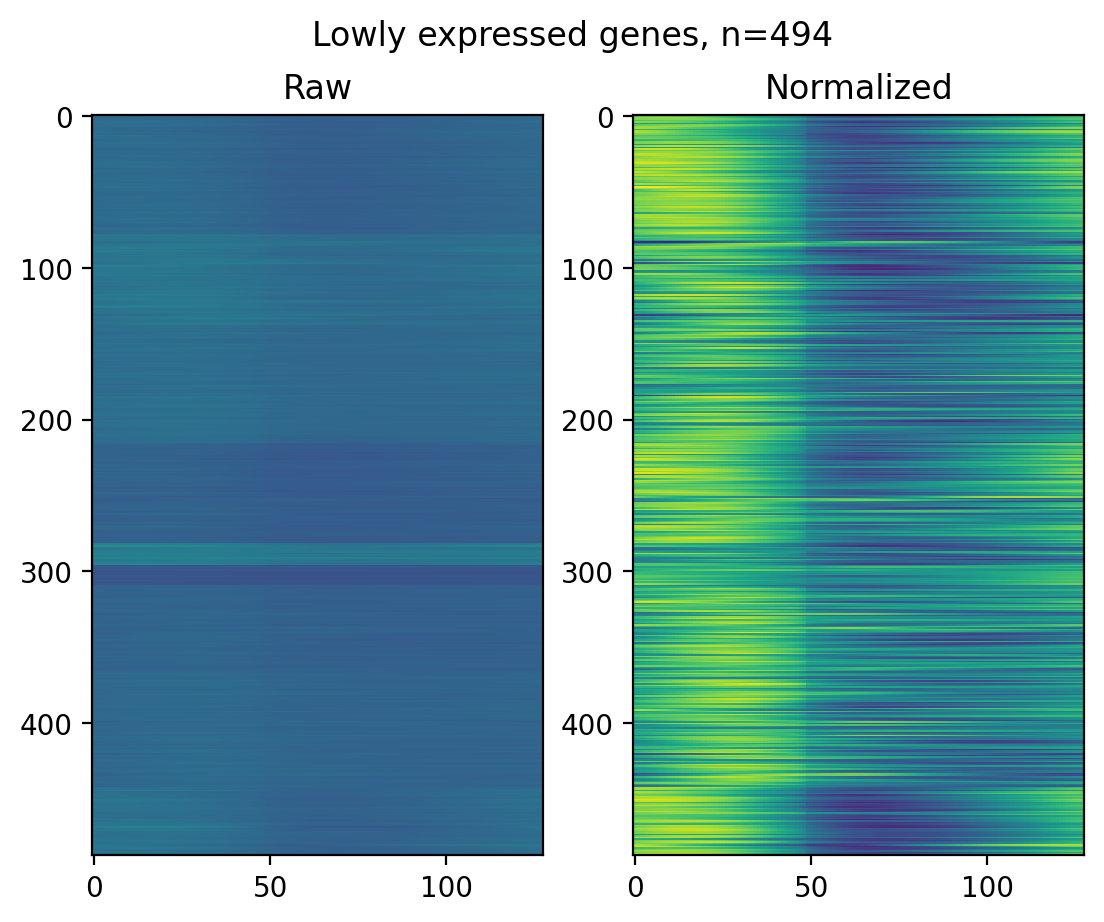

In [17]:
clustered_low_tx_gb = cluster_gb_data(normalized_low_tx_gb, low_tx_gb_nuc_occ)
plt.suptitle(f"Lowly expressed genes, n={len(low_tx_gb_nuc_occ)}")


Text(0.5, 0.98, 'Highly expressed genes, n=445')

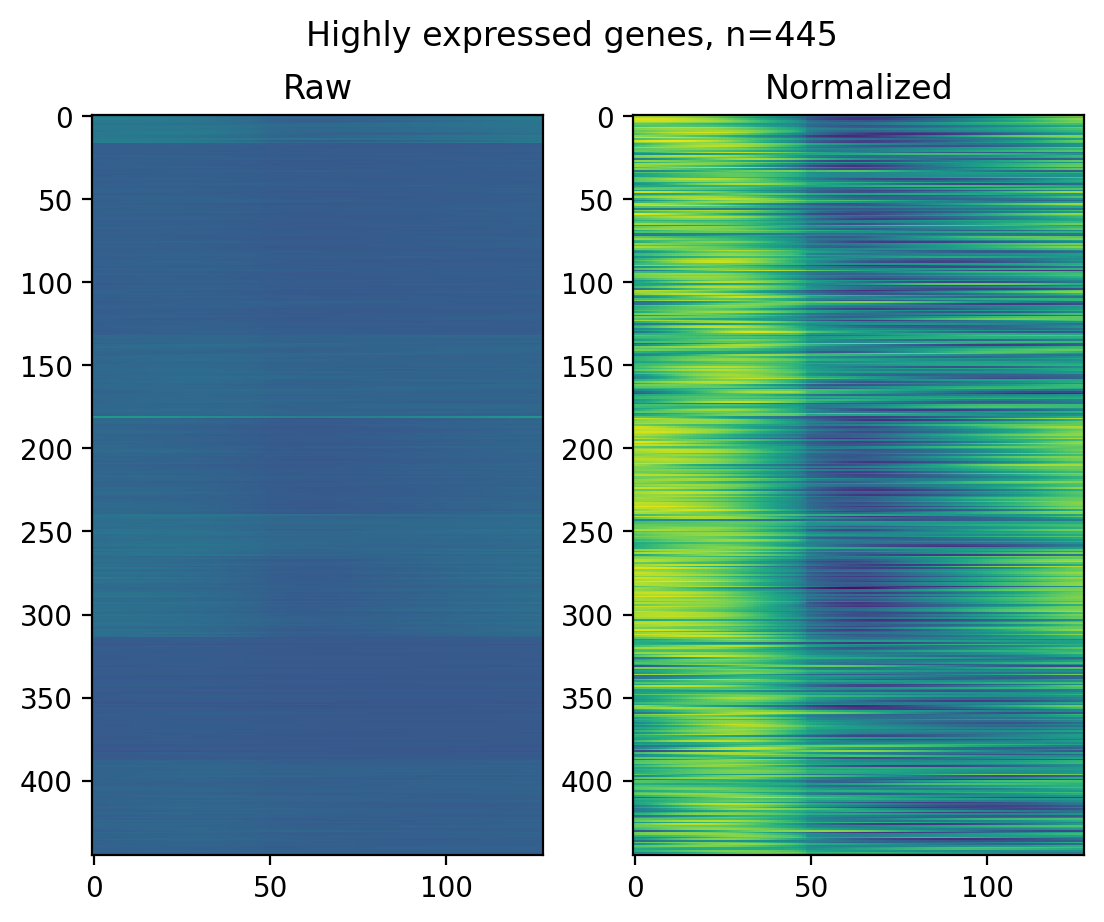

In [18]:
clustered_high_tx_gb = cluster_gb_data(normalized_high_tx_gb, high_tx_gb_nuc_occ)
plt.suptitle(f"Highly expressed genes, n={len(high_tx_gb_nuc_occ)}")

In [19]:
s_g2m_indices = gene_clustering.config.get_Hpositions_for_phase('postG1')

high_std = high_tx_gb_nuc_occ[s_g2m_indices].std(axis=1).mean()
low_std = low_tx_gb_nuc_occ[s_g2m_indices].std(axis=1).mean()

print(f"Genes with a low baseline expression, "
      f"exhibit a higher variation in nucleosome occupancy of {low_std:.2f}")
print(f"Compared to genes with high expression,"
      f"a standard deviation of {high_std:.2f}")
print(f"This appears to show that replication effects on the chromatin are clearest"
      f"with lowly expressed genes.")


Genes with a low baseline expression, exhibit a higher variation in nucleosome occupancy of 46.90
Compared to genes with high expression,a standard deviation of 43.08
This appears to show that replication effects on the chromatin are clearestwith lowly expressed genes.


In [20]:
def compute_box_cluster_vals(clustered_tx_gb):
    from scipy.stats import pearsonr
    clusters = clustered_tx_gb.index.get_level_values(0).unique()
    box_cluster_vals = pd.DataFrame(columns=['n', 'n_acetylation', 
                                             'pearsonr', 'pearsonr_pval',
                                             'sg2m_variation', 
                                             'lower', 'median', 'upper'],
                                    index=clusters)

    for cluster in clusters:
        cluster_orfs = clustered_tx_gb.loc[cluster].index
        
        # The nucleosome variation during S-phase and G2/M
        cluster_gb_std = clustered_tx_gb.loc[cluster][s_g2m_indices].std(axis=1)
        box_cluster_vals.loc[cluster, 'sg2m_variation'] = cluster_gb_std.std()
        
        acetylation_values = genes_h3k56ac.join(pd.DataFrame(index=cluster_orfs), 
            how='inner').mean_acetylation
        
        box_vals = np.quantile(acetylation_values, q=[0.25, 0.5, 0.75])
        box_cluster_vals.loc[cluster, ['lower', 'median', 'upper']] = box_vals

        current_gb_std = clustered_tx_gb.loc[cluster][s_g2m_indices].std(axis=1)\
            .loc[acetylation_values.index]

        if len(acetylation_values) > 1:
            pearsonr_val, pval = pearsonr(acetylation_values, current_gb_std)
        else:
            pearsonr_val = np.nan
            pval = np.nan
                                       
        box_cluster_vals.loc[cluster, 'pearsonr'] = pearsonr_val
        box_cluster_vals.loc[cluster, 'pearsonr_pval'] = pval
        box_cluster_vals.loc[cluster, 'n'] = len(cluster_orfs)
        box_cluster_vals.loc[cluster, 'n_acetylation'] = len(acetylation_values)
        
    return box_cluster_vals


In [21]:
hi_box_cluster_vals = compute_box_cluster_vals(clustered_high_tx_gb)
low_box_cluster_vals = compute_box_cluster_vals(clustered_low_tx_gb)

In [22]:
hi_box_cluster_vals.sort_values('pearsonr')

,n,n_acetylation,pearsonr,pearsonr_pval,sg2m_variation,lower,median,upper
cluster,,,,,,,,
7,49,49,-0.306637,0.032116,29.164425,-0.231923,-0.118889,0.107222
9,57,56,-0.210311,0.11976,14.074551,-0.086,0.281143,0.565
5,58,58,-0.120115,0.369126,20.846401,-0.118036,0.10125,0.461108
8,74,74,-0.082611,0.484087,8.861497,0.330278,0.493968,0.716
2,115,114,-0.052794,0.576936,14.189139,0.087857,0.359846,0.629643
1,17,17,0.018324,0.944353,40.520301,-0.407879,-0.328235,-0.168929
3,49,48,0.032963,0.823991,16.640651,-0.087514,0.0615,0.28
6,25,24,0.174486,0.414813,26.086309,-0.287232,-0.06384,0.136254
4,1,1,NaN,NaN,NaN,-0.15,-0.15,-0.15


In [23]:
low_box_cluster_vals.sort_values('pearsonr')

,n,n_acetylation,pearsonr,pearsonr_pval,sg2m_variation,lower,median,upper
cluster,,,,,,,,
6,13,13,-0.329563,0.2715,8.395125,-0.233333,-0.061923,0.066538
1,78,76,-0.047297,0.684946,20.941126,-0.200417,-0.005556,0.181227
8,75,74,0.03359,0.776326,16.258484,-0.245833,-0.052083,0.166563
2,60,58,0.057127,0.670148,29.721923,-0.284702,0.039286,0.496402
3,78,76,0.058822,0.613744,18.740212,-0.2275,0.006923,0.26125
7,58,58,0.071242,0.59512,15.185306,-0.141571,0.04,0.165063
4,66,64,0.11813,0.352539,24.07774,-0.203737,0.036818,0.162083
9,45,43,0.177907,0.253715,32.757467,-0.145879,0.025556,0.323571
5,14,13,0.445344,0.127247,38.60035,-0.23,0.17,0.24


In [24]:
def compute_compare_gb_h3k56ac(high_tx_gb_nuc_occ):
    
    gb_std = high_tx_gb_nuc_occ[s_g2m_indices].std(axis=1)
    gb_q10 = high_tx_gb_nuc_occ[s_g2m_indices].quantile(q=0.1, axis=1)
    gb_q90 = high_tx_gb_nuc_occ[s_g2m_indices].quantile(q=0.9, axis=1)
    
    gb_s_start = high_tx_gb_nuc_occ[s_g2m_indices[10]]
    gb_g2m_end = high_tx_gb_nuc_occ[s_g2m_indices[-10]]
    
    cur_gene_acetylation = high_tx_gb_nuc_occ[[]].join(genes_h3k56ac, 
        how='left').mean_acetylation
    compare_gb_nuc_df = pd.DataFrame({'gene_body_std': gb_std, 
                                      'gene_body_q10': gb_q10,
                                      'gene_body_q90': gb_q90,
                                      'gene_body_s_start': gb_s_start,
                                      'gene_body_g2m_end': gb_g2m_end,
        'h3k56acetylation': cur_gene_acetylation})
    return compare_gb_nuc_df


In [25]:
high_gb_nuc_df = compute_compare_gb_h3k56ac(high_tx_gb_nuc_occ)
low_gb_nuc_df = compute_compare_gb_h3k56ac(low_tx_gb_nuc_occ)


In [26]:
# selected_cluster = 9
# selected_orfs = clustered_low_tx_gb.loc[selected_cluster].index
# selected_data = low_gb_nuc_df.loc[selected_orfs]

selected_cluster = 6
selected_orfs = clustered_high_tx_gb.loc[selected_cluster].index
selected_data = high_gb_nuc_df.loc[selected_orfs]

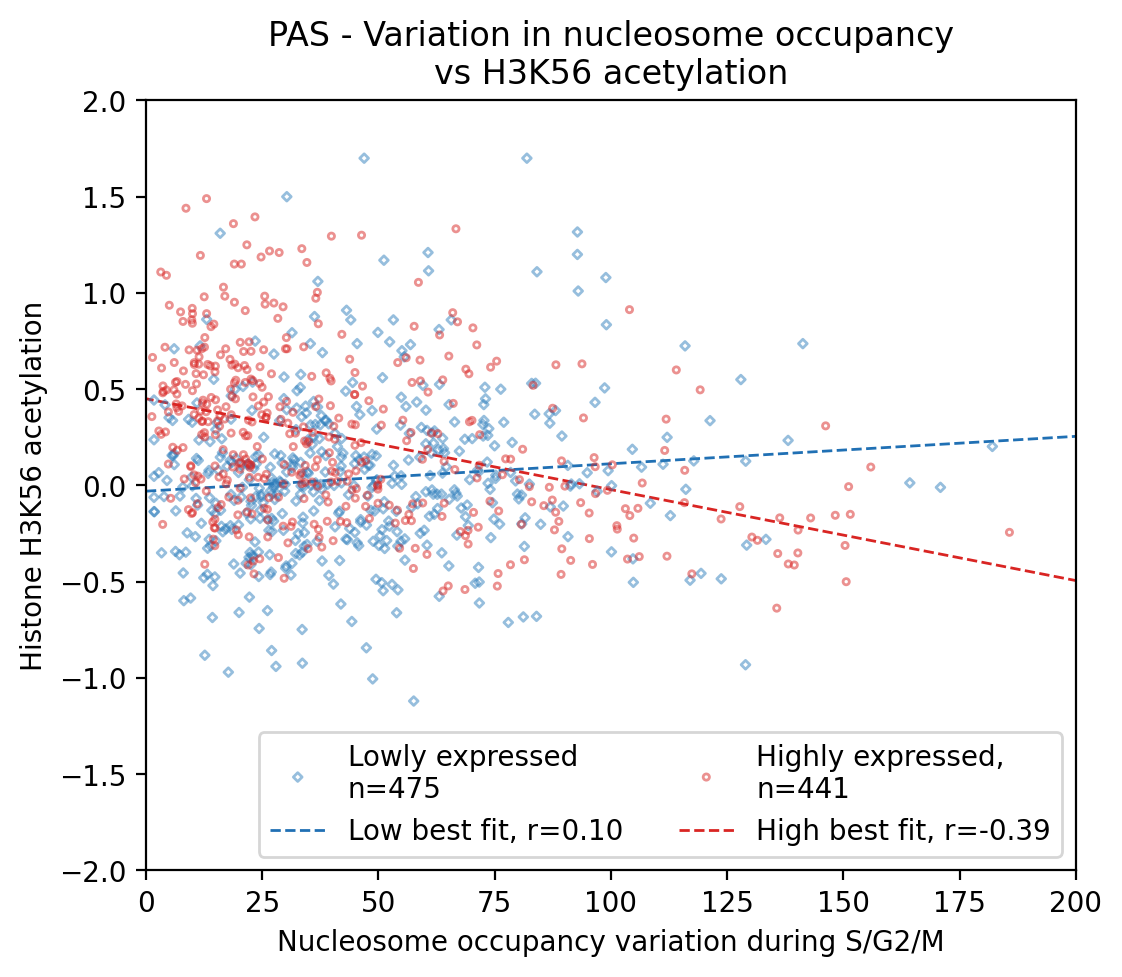

In [27]:
from scipy.stats import pearsonr
from src.figure_configs import FiguresConfig, save_figure_for_paper

def draw_bestfit(x, y, color, label):
    m, b = np.polyfit(x, y, 1)
    fit_xs = np.array([-1000, 1000])
    fit_ys = fit_xs*m + b
    plt.plot(fit_xs, fit_ys, color=color, 
        lw=1, ls='dashed', zorder=0, label=label)
    
plt.figure(figsize=(6, 5))
x, y = low_gb_nuc_df.dropna().gene_body_std.values.astype(float), \
    low_gb_nuc_df.dropna()['h3k56acetylation'].values.astype(float)
pearsonr_res, _ = pearsonr(x, y)
plt.scatter(x, y,
           label=f"Lowly expressed\nn={len(x)}", 
            marker='D', facecolor='none',
           edgecolor=plt.get_cmap("Blues")(0.7), alpha=0.5, s=5)
draw_bestfit(x, y, plt.get_cmap('Blues')(0.75),
            label=f"Low best fit, r={pearsonr_res:.2f}")

x, y = high_gb_nuc_df.dropna().gene_body_std.values.astype(float), \
    high_gb_nuc_df.dropna()['h3k56acetylation'].values.astype(float)
pearsonr_res, _ = pearsonr(x, y)
plt.scatter(x, y, 
            label=f"Highly expressed,\nn={len(x)}", 
            edgecolor=plt.get_cmap('Reds')(0.7),
            facecolor='none', marker='o', alpha=0.5, s=5)
draw_bestfit(x, y, plt.get_cmap('Reds')(0.7),
            label=f"High best fit, r={pearsonr_res:.2f}")

# plt.scatter(selected_data.gene_body_std, selected_data['h3k56acetylation'],
#           label=f"Selected cluster {selected_cluster}", marker='X', 
#            color=plt.get_cmap('Greens')(0.5), edgecolor='none', lw=1, alpha=1, s=15)

plt.xlabel("Nucleosome occupancy variation during S/G2/M")
plt.ylabel("Histone H3K56 acetylation")
plt.legend(loc='lower right', ncol=2)

plt.xlim(0, 200)
plt.ylim(-2, 2)
plt.title("PAS - Variation in nucleosome occupancy\nvs H3K56 acetylation")
save_figure_for_paper('output/figures/Buffering/PAS_nuc_H3K56ac.png')

In [28]:
# High acetylation, high expression -> low nucleosome variability
# 0 acetylation, high expression -> high nucleosome variability
sorted_high_tx_genes = high_gb_nuc_df.sort_values('h3k56acetylation').dropna()
high_acetyl_high_tx_genes = sorted_high_tx_genes.tail(100)
low_acetyl_high_tx_genes = sorted_high_tx_genes.head(100)


In [29]:
high_acetyl_high_f_imgs, _ = \
    analysis.load_stacked_mnase_data_for_genes(high_acetyl_high_tx_genes, padding=1000,
                                              center_mode='PAS_nuc', compute_gb_occ=True)

low_acetyl_high_f_imgs, _ = \
    analysis.load_stacked_mnase_data_for_genes(low_acetyl_high_tx_genes, padding=1000,
                                              center_mode='PAS_nuc', compute_gb_occ=True)



Text(0.5, 0.98, 'Highly expressed, high acetylation genes, n=100')

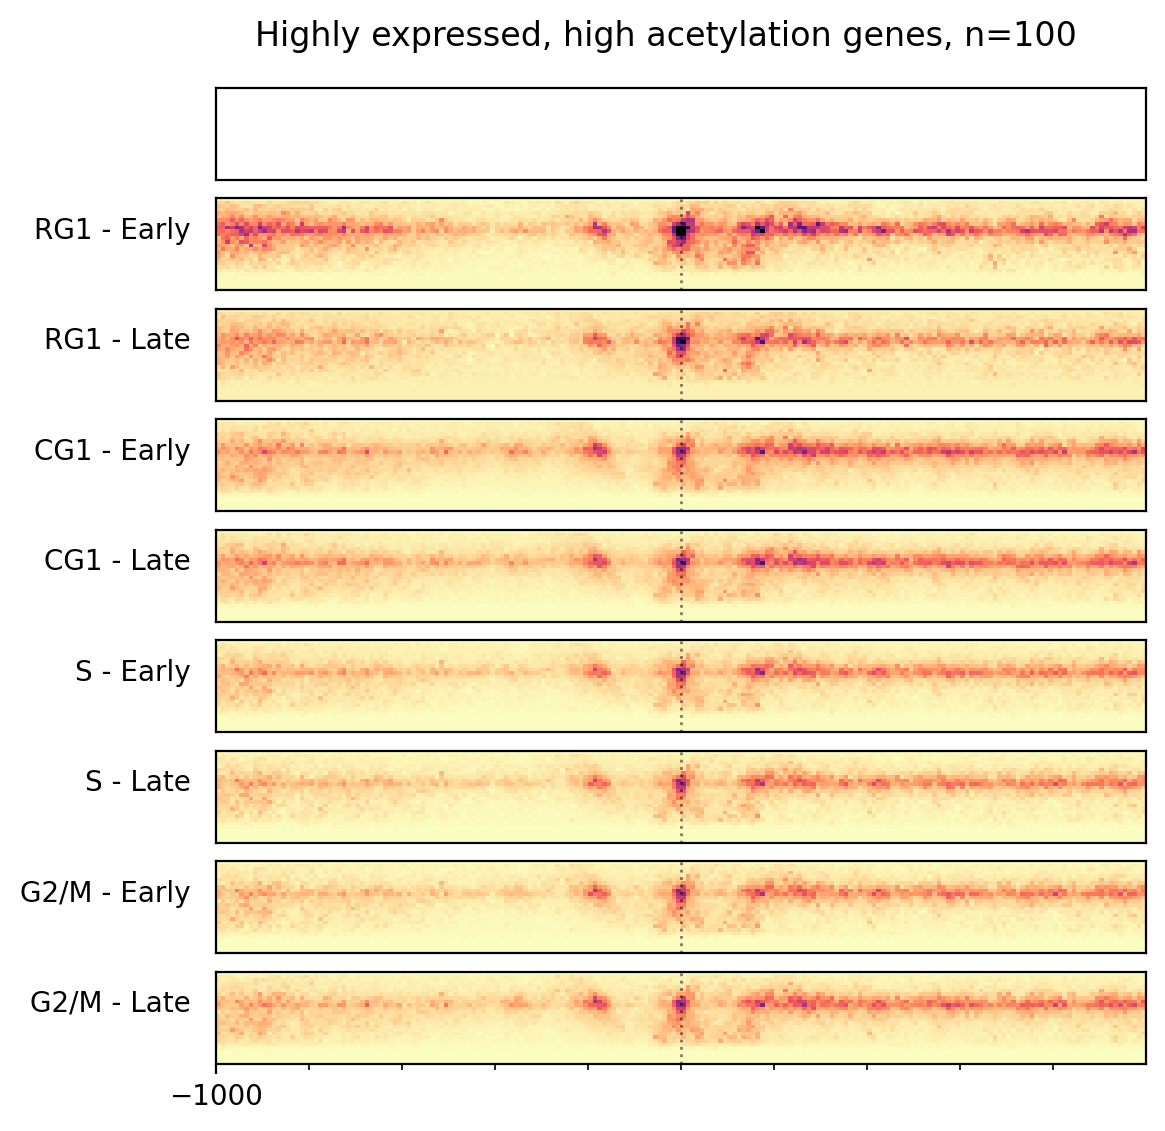

In [30]:
fig = analysis.plot_deconvolved_result(high_acetyl_high_f_imgs, (-1000, 1000), 
                                       figsize=(6, 6),
                                      vmax=5)
plt.suptitle(f"Highly expressed, high acetylation genes, n={len(high_acetyl_high_tx_genes)}")

Text(0.5, 0.98, 'Highly expressed, low acetylation genes, n=100')

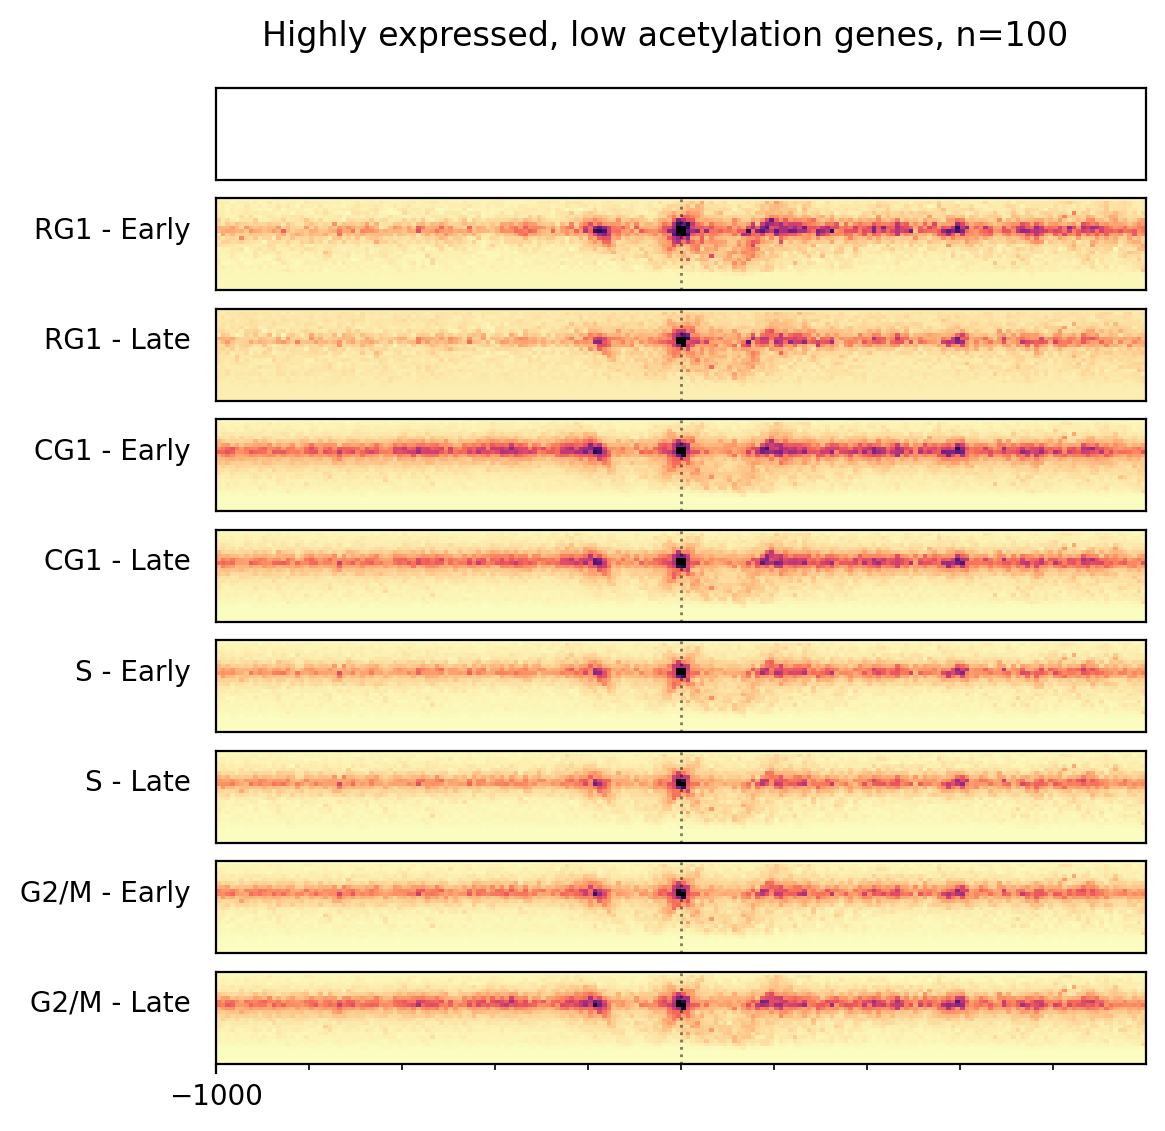

In [31]:
fig = analysis.plot_deconvolved_result(low_acetyl_high_f_imgs, (-1000, 1000), 
                                       figsize=(6, 6),
                                      vmax=5)
plt.suptitle(f"Highly expressed, low acetylation genes, n={len(low_acetyl_high_tx_genes)}")

In [32]:
from src.panther_go import PantherDBGO

panthergo = PantherDBGO()

cluster_go_df = pd.DataFrame()
for selected_cluster in np.arange(n_clusters)+1:

    selected_orfs = clustered_high_tx_gb.loc[selected_cluster].index
    selected_gene_names = genes.loc[selected_orfs]['gene']

    panthergo.run_go(selected_gene_names)
    panthergo.parse_response()
    go_results = panthergo.results_df.sort_values('fdr')

    go_results['cluster'] = selected_cluster
        
    cluster_go_df = pd.concat([cluster_go_df, go_results])


In [33]:
cluster_go_df[(cluster_go_df.cluster == 6) & 
              (cluster_go_df.number_in_reference < 100) &
              (cluster_go_df.fdr < 0.001)][['label', 'fdr']]

,label,fdr


In [34]:
# Next question, if we were to normalize the gene windows prior to 
# computing the gene body nucleosome occupancy, would we still get the same result?

In [35]:
# It appears that the lowest standard deviation is due to low amounts of nucleosome occupancy
# moreso than variation in occupancy, as almost all genes show the same amount
# of variation in the same places (low in the start of S and high at the end of S...)
# Systematic observation....

# Options: 
# 1. Find out how to handle this observation (normalize it somehow)
# 2. Continue as expected, the result still stands that the PAS is showing a negative
# correlation in H3K56ac in highly expressed genes but not in the TSS or any other
# sets of genes, why is that?
# 
# Does the end of the gene body indicate something moreso than the start? It tends to
# have fewer nucleosome reads (more variation and less deconvolved signal than the start
# of the genes...)
#


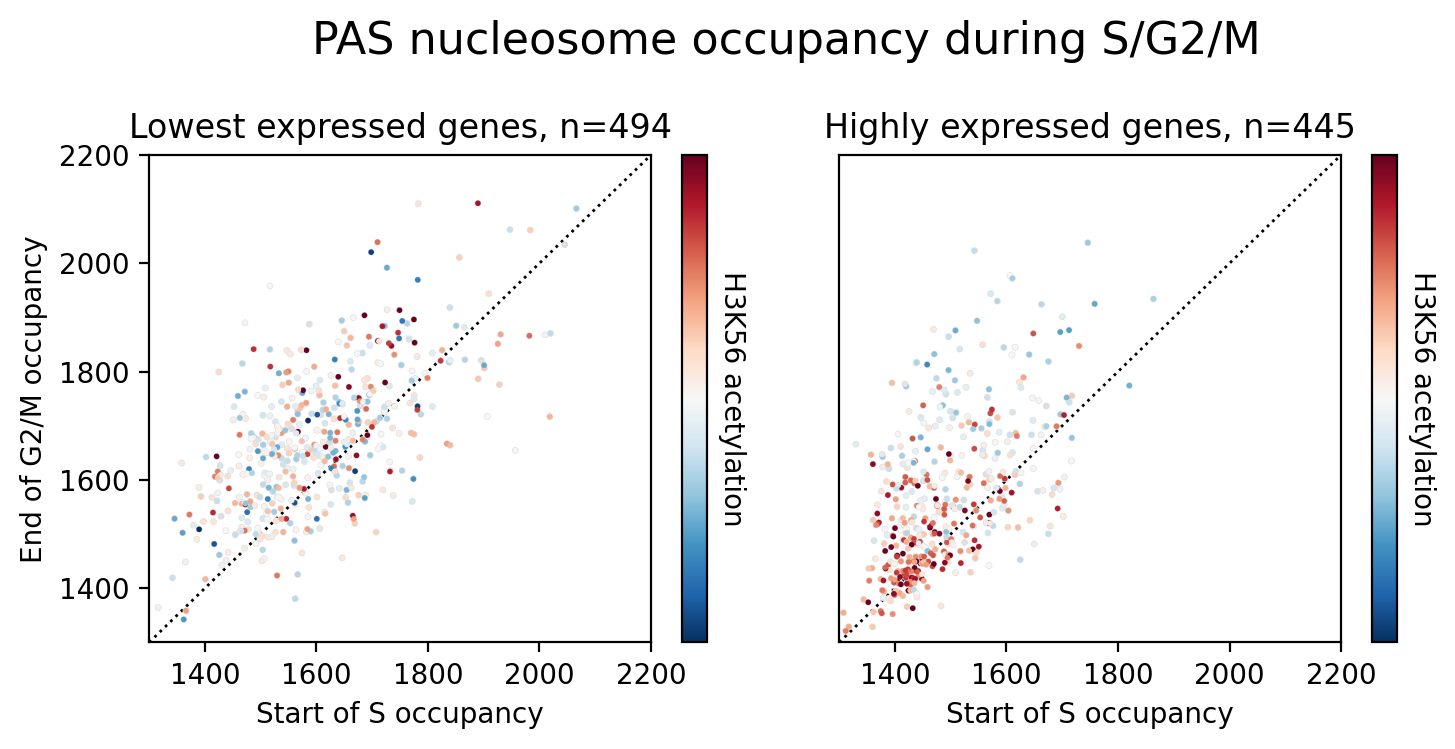

In [37]:
from src.figure_configs import FiguresConfig

plt.figure(figsize=(8.5, 3.75))

plt.subplot(1, 2, 1)
plt.scatter(low_gb_nuc_df.gene_body_s_start, low_gb_nuc_df.gene_body_g2m_end, s=2,
           edgecolor='#dddddd', facecolor='none')
plt.scatter(low_gb_nuc_df.gene_body_s_start, low_gb_nuc_df.gene_body_g2m_end, s=1,
           c=low_gb_nuc_df.h3k56acetylation, vmax=1, vmin=-1, cmap='RdBu_r')
cbar = plt.colorbar()
cbar.ax.set_yticks([])
cbar.ax.set_ylabel("H3K56 acetylation", rotation=270, va='bottom')

plt.title(f"Lowest expressed genes, n={len(low_gb_nuc_df)}")
plt.xlabel("Start of S occupancy")
plt.ylabel("End of G2/M occupancy")
plt.ylim(1300, 2200)
plt.xlim(1300, 2200)
plt.plot([0, 3000], [0, 3000], c='black', lw=1, ls='dotted', zorder=0)



plt.subplot(1, 2, 2)
plt.scatter(high_gb_nuc_df.gene_body_s_start, high_gb_nuc_df.gene_body_g2m_end, s=2,
           edgecolor='#dddddd', facecolor='none')
plt.scatter(high_gb_nuc_df.gene_body_s_start, high_gb_nuc_df.gene_body_g2m_end, s=1,
           c=high_gb_nuc_df.h3k56acetylation, vmax=1, vmin=-1, cmap='RdBu_r')
plt.xlabel("Start of S occupancy")
plt.title(f"Highly expressed genes, n={len(high_gb_nuc_df)}")
plt.ylim(1300, 2200)
plt.xlim(1300, 2200)
plt.yticks([])
cbar = plt.colorbar()
cbar.ax.set_yticks([])
plt.plot([0, 3000], [0, 3000], c='black', lw=1, ls='dotted', zorder=0)
cbar.ax.set_ylabel("H3K56 acetylation", rotation=270, va='bottom')

plt.suptitle("PAS nucleosome occupancy during S/G2/M", 
    fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
plt.subplots_adjust(top=0.8, wspace=0.1, bottom=0.15)
save_figure_for_paper("output/figures/Buffering/PAS_occupancy.png")

In [38]:
low_gb_nuc_df[low_gb_nuc_df.gene_body_s_start > 400]

,gene_body_std,gene_body_q10,gene_body_q90,gene_body_s_start,gene_body_g2m_end,h3k56acetylation
orf_name,,,,,,
YPL038W-A,98.643038,1545.793839,1807.543551,1550.001637,1800.292347,0.506667
YGL249W,59.831543,1677.089339,1837.519584,1682.520012,1834.226354,-0.232857
YOR010C,15.572518,1428.784013,1469.119651,1441.975782,1466.440894,0.078750
YPR001W,21.850498,1626.895501,1684.478544,1657.742738,1674.706486,0.106364
YKR097W,89.761202,1503.44141,1743.745398,1519.347646,1735.577014,-0.107059
...,...,...,...,...,...,...
YLR307C-A,66.868105,1853.64603,2028.02302,2019.654552,1870.509635,-0.258000
YPR193C,13.782381,1558.703688,1595.669437,1560.2233,1594.479855,0.228000
YPR192W,33.249517,1362.130696,1450.969361,1365.184312,1448.622191,-0.045000


In [39]:
# Observations:
# - Highly expressed genes whose nucleosome occupancy is close to 0 are highly acetylated
#   low occupancy throughout the entirety of S/G2/M
# - Previously they were coming up as the least variable in occupancy, but this
#   was mainly because the occupancy was low
#
# Now: We can find examples of H3K56ac and non acetylated genes


In [40]:
ac_sorted_high_tx_genes = high_gb_nuc_df.sort_values('h3k56acetylation')
high_tx_high_ac_genes = ac_sorted_high_tx_genes.tail(100)
high_tx_low_ac_genes = ac_sorted_high_tx_genes.head(100)

len(high_tx_high_ac_genes), len(high_tx_low_ac_genes)


(100, 100)

In [41]:
ac_sorted_low_tx_genes = low_gb_nuc_df.sort_values('h3k56acetylation')
low_tx_high_ac_genes = ac_sorted_low_tx_genes.tail(100)
low_tx_low_ac_genes = ac_sorted_low_tx_genes.head(100)

len(low_tx_low_ac_genes), len(low_tx_high_ac_genes)


(100, 100)

In [62]:
from src.GenomeDeconvolutionAnalysis import plot_tss_pas_chrom

In [43]:
from src.chromatin_model import draw_phase_label_annotations

config = gene_clustering.config
high_color = plt.get_cmap('Reds')(0.75)
low_color = plt.get_cmap('Blues')(0.75)

def plot_expression_timecourse(gene_clustering, high_tx_high_ac_genes, high_tx_low_ac_genes,
                              title, ylim,
                              labels=['Low H3K56 acetylation', 'High H3K56 acetylation']):

    t_timepoints = config.get_timepoints_for_branch('t')

    plt.figure(figsize=(6, 4))
    qvals_high_ac = gene_clustering.gene_expression.loc[high_tx_high_ac_genes.index][t_indices]\
        .quantile(q=[0.25, 0.5, 0.75], axis=0).dropna().astype(float)

    qvals_low_ac = gene_clustering.gene_expression.loc[high_tx_low_ac_genes.index][t_indices]\
        .quantile(q=[0.25, 0.5, 0.75], axis=0).dropna().astype(float)

    plt.fill_between(t_timepoints, qvals_high_ac.loc[0.25].values, 
                     qvals_high_ac.loc[0.75].values, alpha=0.35, color=high_color,
                     label=f"{labels[1]}, n={len(high_tx_high_ac_genes)}")
    plt.plot(t_timepoints, qvals_high_ac.loc[0.5], color=high_color)

    plt.fill_between(t_timepoints, qvals_low_ac.loc[0.25].values, 
                     qvals_low_ac.loc[0.75].values, alpha=0.35,
                     label=f"{labels[0]}, n={len(high_tx_low_ac_genes)}",
                     color=low_color)
    plt.plot(t_timepoints, qvals_low_ac.loc[0.5], color=low_color)
    plt.suptitle(title,
             fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
    plt.legend()

    ax = plt.gca()
    draw_phase_label_annotations(ax, config, flip=True, annotations_x=ylim[0]+.25)
    plt.xticks([])
    plt.xlim(t_timepoints[0], t_timepoints[-1])
    plt.yticks(np.arange(ylim[0]//1, ylim[1]+1, 1))
    plt.ylim(*ylim)
    plt.subplots_adjust(top=0.82)

    plt.ylabel("Deconvolved expression, VST")


In [446]:
t_timepoints = config.get_timepoints_for_branch('t')
def plot_chromatin_timecourse(high_tx_gb_nuc_occ, high_tx_high_ac_genes, high_tx_low_ac_genes,
                          title, labels=[
                              'Low H3K56 acetylation',
                              'High H3K56 acetylation'
                          ], annotations_offset=0, 
                              ylim=(1400, 2000),
                           ylabel="Nucleosome occupancy",
                           high_color=plt.get_cmap('Reds')(0.75),
                           low_color=plt.get_cmap('Blues')(0.75)):
    fig = plt.figure(figsize=(6, 4))

    qvals_high_ac = high_tx_gb_nuc_occ.loc[high_tx_high_ac_genes.index][t_indices]\
        .quantile(q=[0.25, 0.5, 0.75], axis=0).dropna().astype(float)

    qvals_low_ac = high_tx_gb_nuc_occ.loc[high_tx_low_ac_genes.index][t_indices]\
        .quantile(q=[0.25, 0.5, 0.75], axis=0).dropna().astype(float)

    plt.fill_between(t_timepoints, qvals_high_ac.loc[0.25].values, 
                     qvals_high_ac.loc[0.75].values, alpha=0.35, color=high_color,
                     label=f"{labels[1]}, n={len(high_tx_high_ac_genes)}")
    plt.plot(t_timepoints, qvals_high_ac.loc[0.5], color=high_color)

    plt.fill_between(t_timepoints, qvals_low_ac.loc[0.25].values, 
                     qvals_low_ac.loc[0.75].values, alpha=0.35, color=low_color,
                     label=f"{labels[0]}, n={len(high_tx_low_ac_genes)}")
    plt.plot(t_timepoints, qvals_low_ac.loc[0.5],  color=low_color)
    plt.suptitle(title,
             fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
    plt.legend()

    ax = plt.gca()
    draw_phase_label_annotations(ax, config, flip=True, annotations_x=ylim[0]+annotations_offset)
    plt.xticks([])
    plt.xlim(t_timepoints[0], t_timepoints[-1])
    plt.ylim(*ylim)
    plt.ylabel(ylabel)
    plt.subplots_adjust(top=0.82)



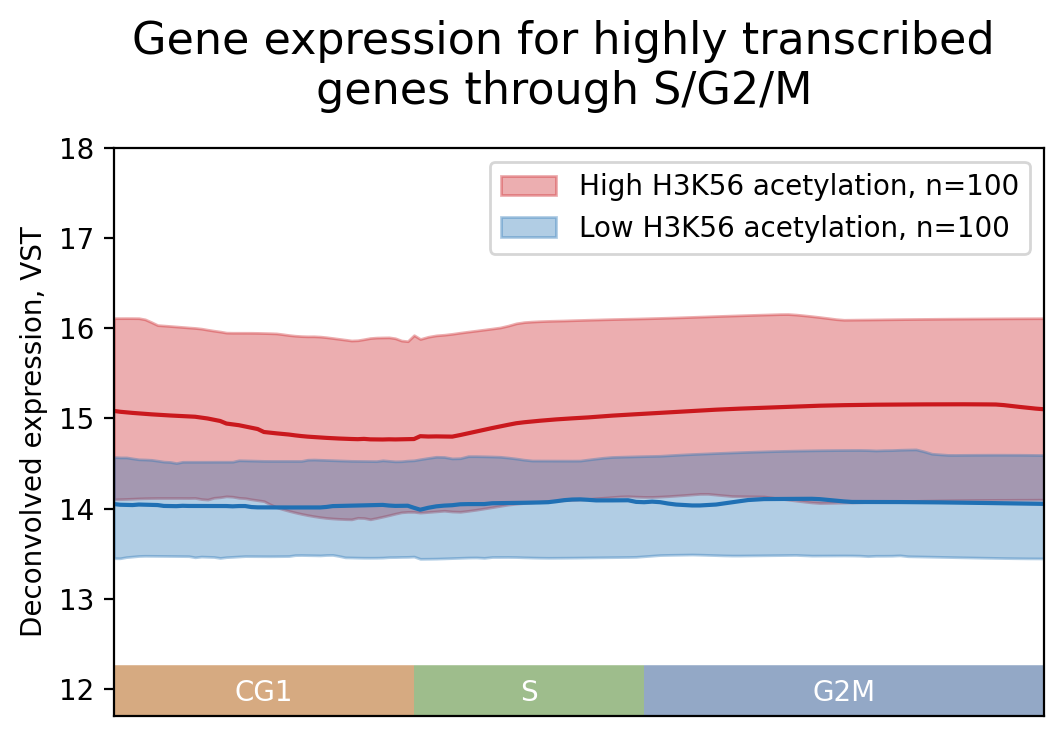

In [45]:
title="Gene expression for highly transcribed\ngenes through S/G2/M"
plot_expression_timecourse(gene_clustering, high_tx_high_ac_genes, high_tx_low_ac_genes,
                          title, ylim=(11.7, 18))
save_figure_for_paper('output/figures/Buffering/'
                      'Timecourse_gene_expression_high_expression.png')


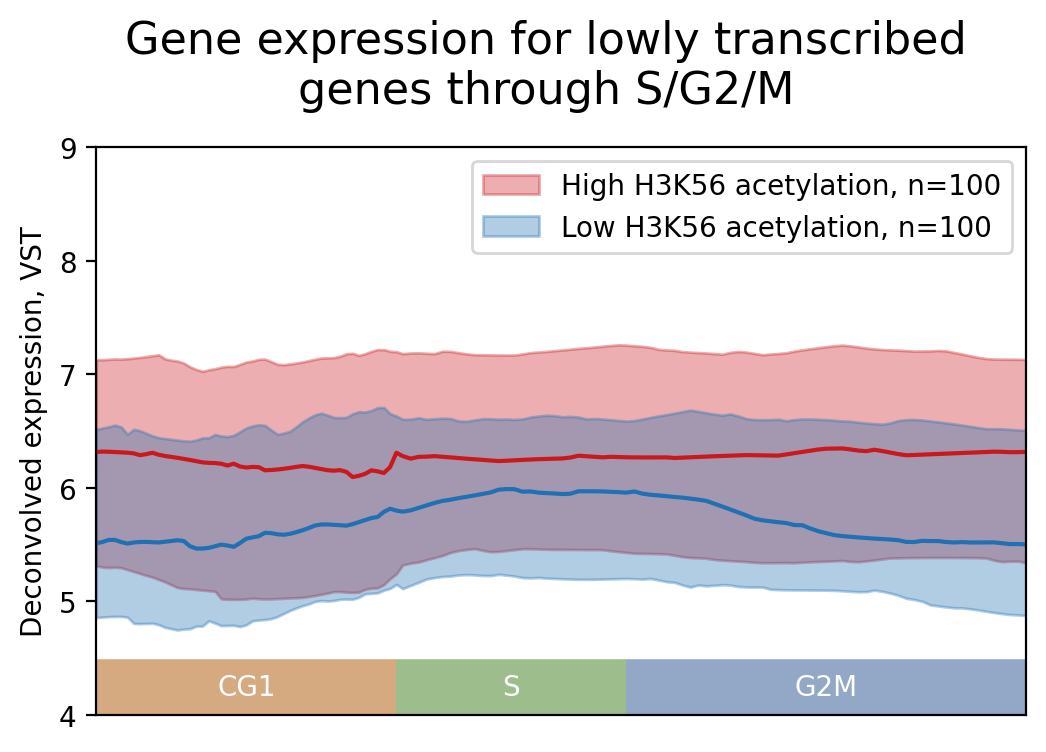

In [46]:
title="Gene expression for lowly transcribed\ngenes through S/G2/M"
plot_expression_timecourse(gene_clustering, low_tx_high_ac_genes, low_tx_low_ac_genes,
                          title, ylim=(4, 9))
save_figure_for_paper('output/figures/Buffering/'
                      'Timecourse_gene_expression_low_expression.png')


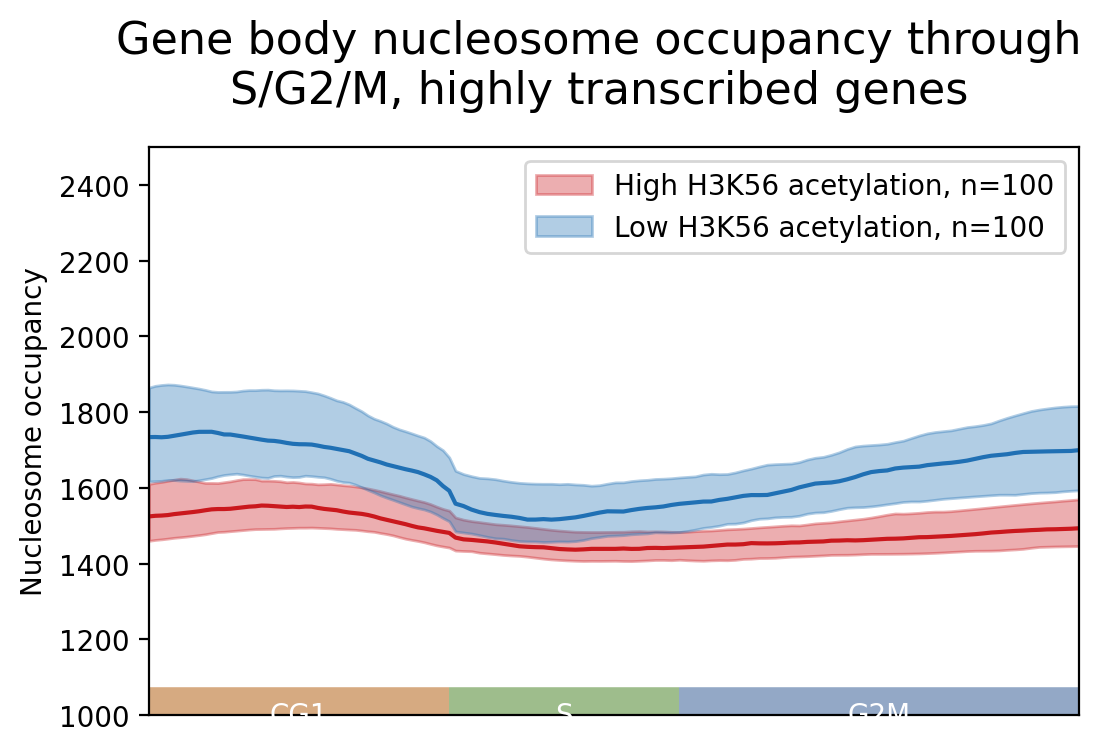

In [47]:
title=f"Gene body nucleosome occupancy through\nS/G2/M, highly transcribed genes"
plot_gb_nuc_timecourse(high_tx_gb_nuc_occ, high_tx_high_ac_genes, high_tx_low_ac_genes, title)
save_figure_for_paper('output/figures/Buffering/Timecourse_PAS_nucleosome_occupancy_high_expression.png')

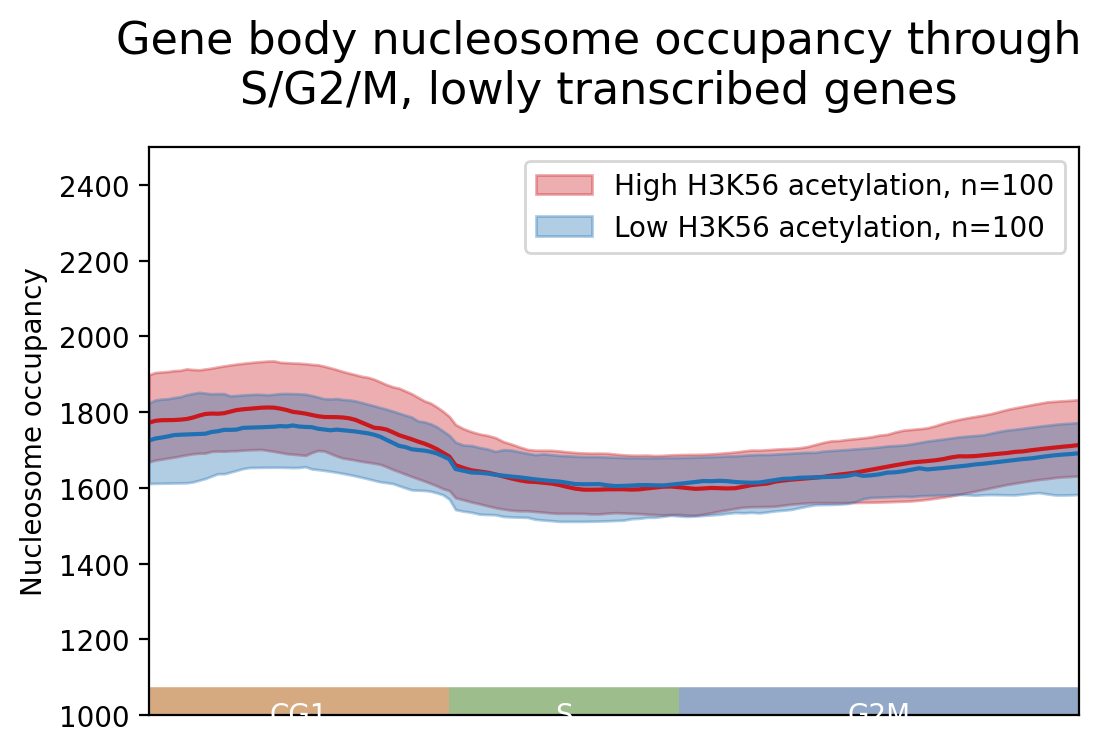

In [48]:
title=f"Gene body nucleosome occupancy through\nS/G2/M, lowly transcribed genes"
plot_gb_nuc_timecourse(low_tx_gb_nuc_occ, low_tx_high_ac_genes, 
                       low_tx_low_ac_genes, title)
save_figure_for_paper(
    'output/figures/Buffering/Timecourse_PAS_nucleosome_occupancy_low_expression.png')

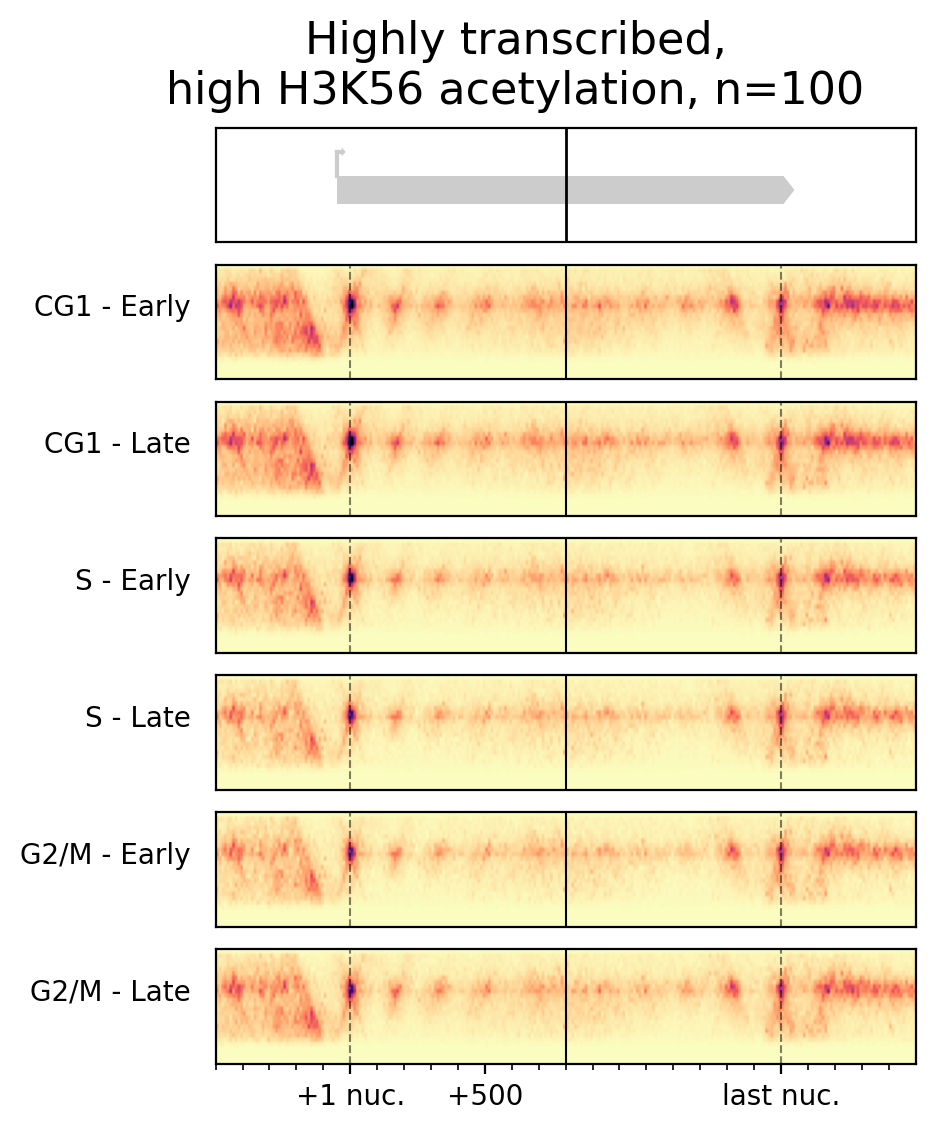

In [49]:
fig = plot_tss_pas_chrom(high_tx_high_ac_genes)
plt.suptitle(f"Highly transcribed,\nhigh H3K56 acetylation, n={len(high_tx_high_ac_genes)}",
            fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
save_figure_for_paper('output/figures/Buffering/Chromatin_high_expression_high_acetylation.png')

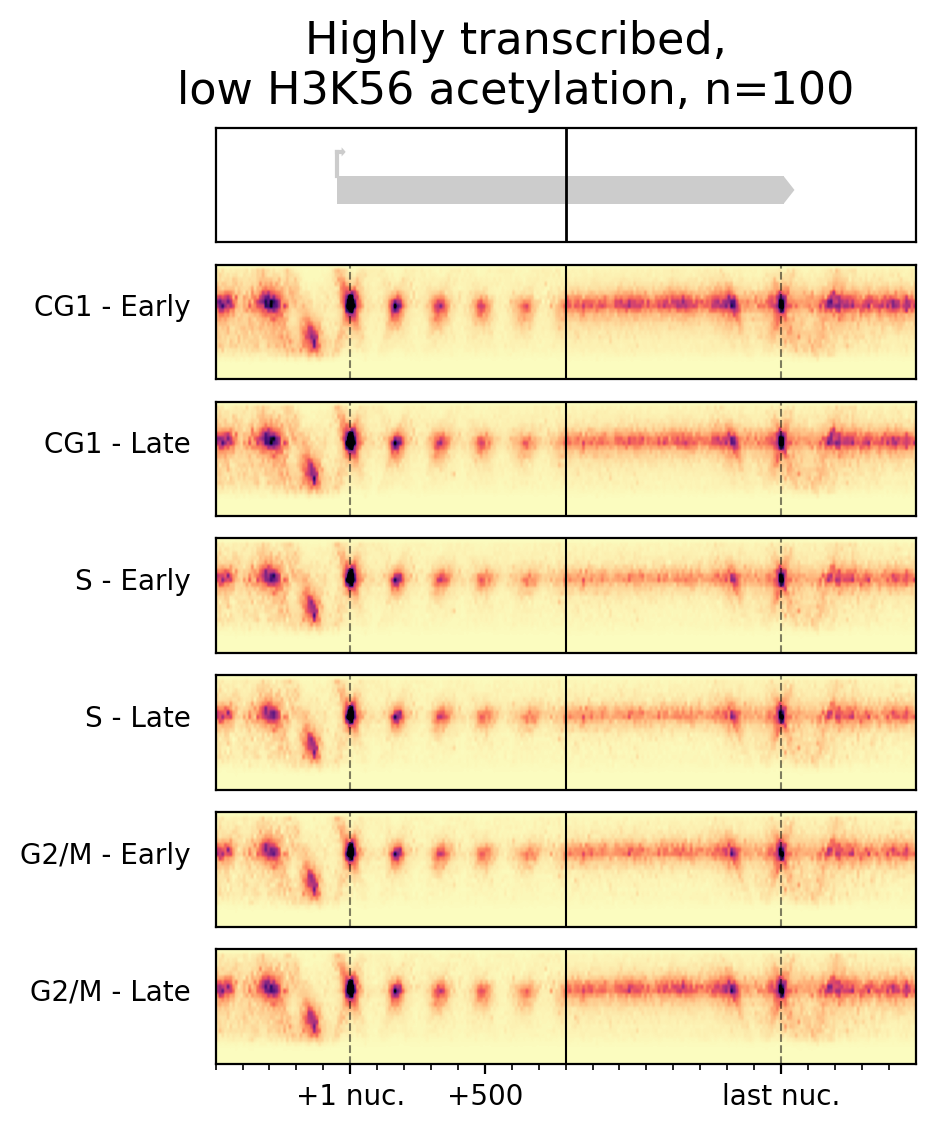

In [50]:
fig = plot_tss_pas_chrom(high_tx_low_ac_genes)
plt.suptitle(f"Highly transcribed,\nlow H3K56 acetylation, n={len(high_tx_low_ac_genes)}",
            fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
save_figure_for_paper('output/figures/Buffering/Chromatin_high_expression_low_acetylation.png')

Failed to load 1 files
Failed to load 3 files


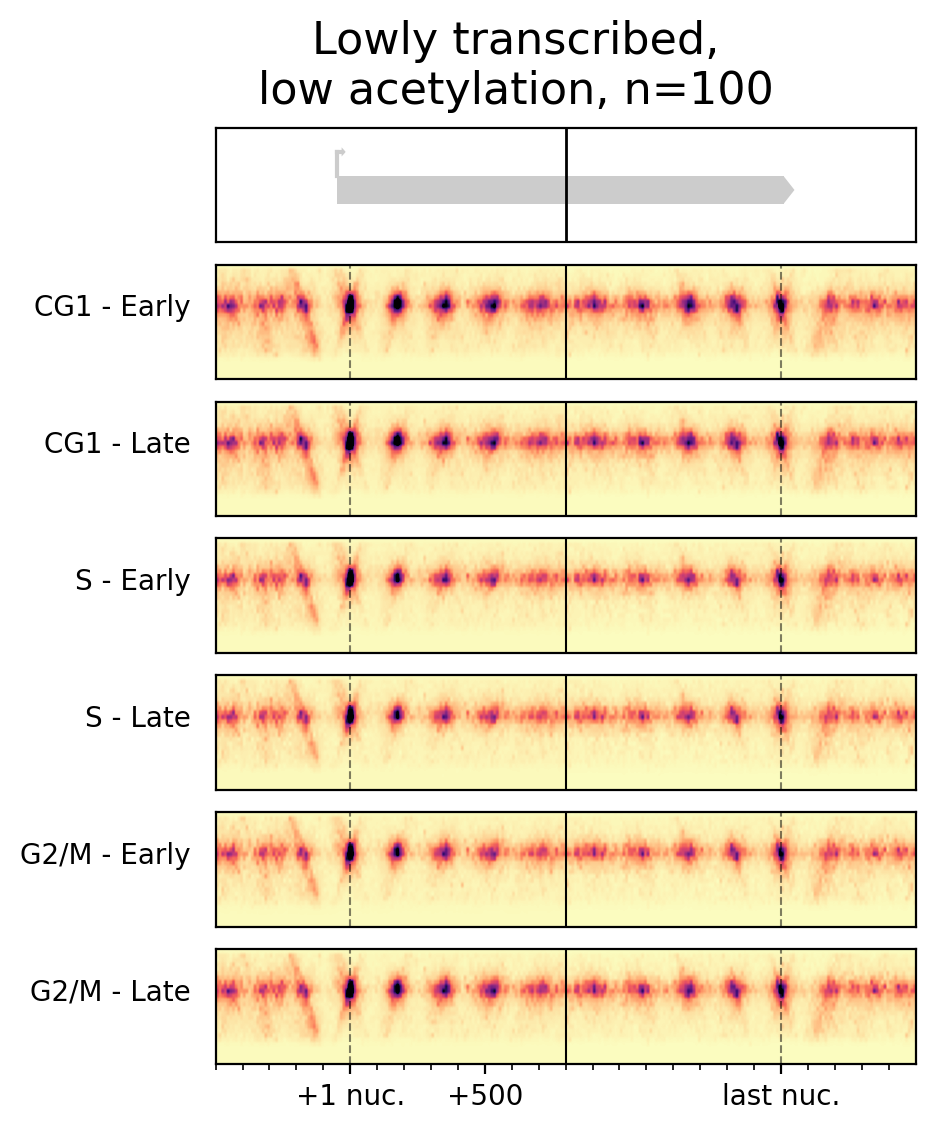

In [51]:
fig = plot_tss_pas_chrom(low_tx_low_ac_genes)
plt.suptitle(f"Lowly transcribed,\nlow acetylation, n={len(low_tx_low_ac_genes)}",
            fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
save_figure_for_paper('output/figures/Buffering/Chromatin_low_expression_low_acetylation.png')

Failed to load 2 files
Failed to load 2 files


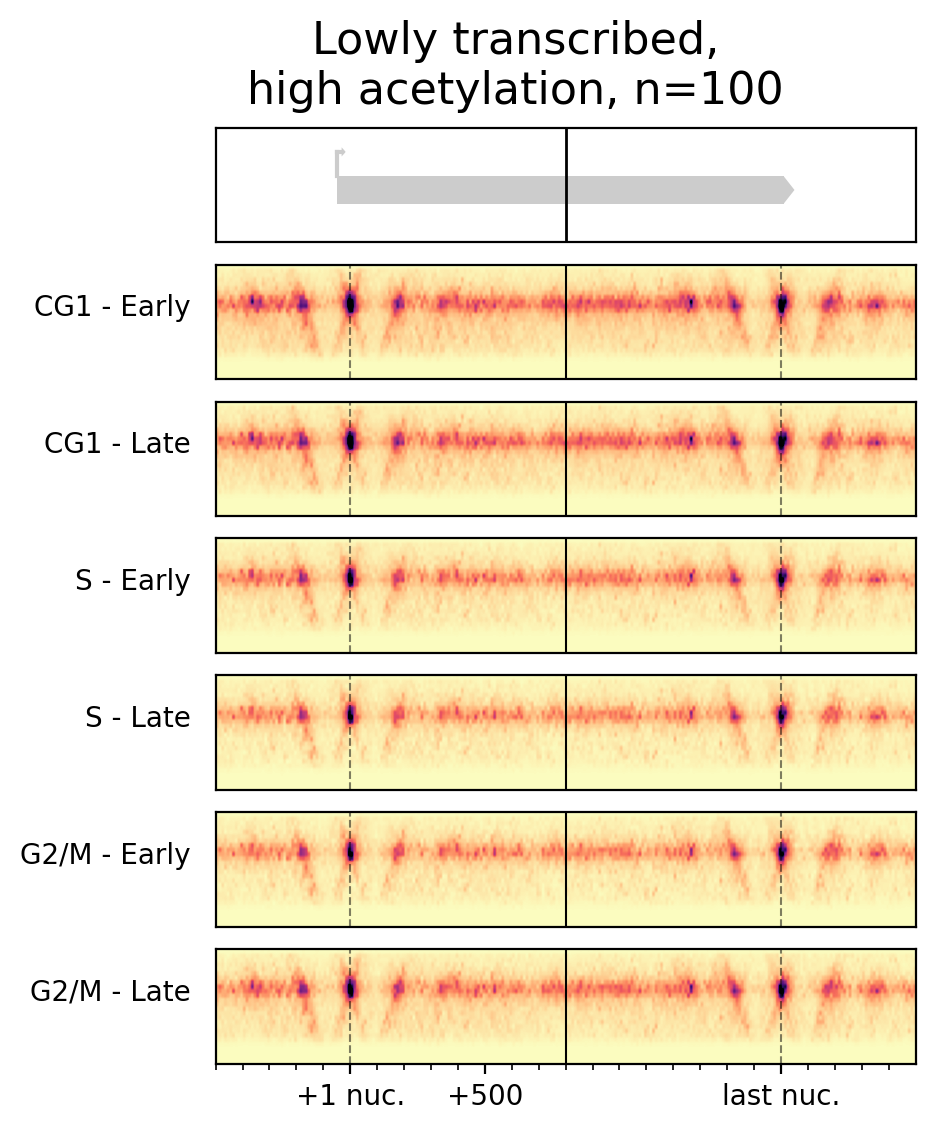

In [52]:
fig = plot_tss_pas_chrom(low_tx_high_ac_genes)
plt.suptitle(f"Lowly transcribed,\nhigh acetylation, n={len(low_tx_high_ac_genes)}",
            fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
save_figure_for_paper('output/figures/Buffering/Chromatin_low_expression_high_acetylation.png')

In [53]:
all_f_genes, all_pas_gb_nuc_occ = analysis.load_stacked_mnase_data_for_genes(
    genes, padding=1000, center_mode='PAS_nuc', compute_gb_occ=True)

Failed to load 11 files


In [93]:

# Compute the PAS nucleosome entropy for all genes.
from src.GenomeDeconvolutionAnalysis import compute_entropy_func
_, all_pas_gb_nuc_entropy = analysis.load_stacked_mnase_data_for_genes(
    genes, padding=1000, center_mode='PAS_nuc', compute_custom_func=compute_entropy_func)


In [95]:
all_pas_gb_nuc_entropy

,0,1,2,3,4,5,6,7,8,9,...,168,169,170,171,172,173,174,175,176,177
orf_name,,,,,,,,,,,,,,,,,,,,,
YDR006C,9.878353,9.888906,9.906775,9.935502,9.972351,10.004711,10.032356,10.057036,10.080018,10.102732,...,10.08015,10.081082,10.08193,10.082664,10.083384,10.084055,10.084477,10.084677,10.084317,9.983255
YEL044W,9.864491,9.868853,9.876978,9.890067,9.907396,9.924929,9.942079,9.958795,9.974786,9.990719,...,10.095028,10.09292,10.090759,10.08859,10.086439,10.084347,10.082785,10.081895,10.081323,9.830153
YMR137C,9.335419,9.339801,9.347849,9.360803,9.378008,9.395678,9.413223,9.43055,9.447192,9.464057,...,9.798766,9.799645,9.800456,9.801185,9.801862,9.802523,9.802977,9.80338,9.803914,9.698295
YKR027W,9.999117,10.003806,10.012316,10.025902,10.043756,10.061558,10.078761,10.095265,10.110645,10.125885,...,10.107594,10.107812,10.108022,10.108179,10.108406,10.108644,10.108731,10.108742,10.108283,10.021885
YER168C,9.865123,9.869272,9.877089,9.889843,9.906866,9.924252,9.941484,9.958333,9.974349,9.990447,...,10.083686,10.08356,10.083443,10.083326,10.083232,10.08318,10.083177,10.083333,10.083731,9.927996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YMR032W,9.82318,9.826221,9.831852,9.8409,9.852622,9.864299,9.875525,9.886283,9.896289,9.905703,...,10.167879,10.167402,10.166953,10.166532,10.166206,10.165945,10.165798,10.165783,10.165418,-inf
YDR089W,9.76525,9.770331,9.779767,9.795357,9.816576,9.838607,9.860835,9.883096,9.904845,9.927702,...,10.000822,10.000688,10.000596,10.000527,10.00053,10.000606,10.00069,10.000859,10.001031,9.752736
YJR011C,9.727106,9.732795,9.743211,9.760327,9.783434,9.807078,9.830582,9.853949,9.876476,9.899672,...,10.070643,10.070668,10.070666,10.070629,10.070593,10.070556,10.070513,10.070525,10.070451,9.905066


Text(0.5, 1.0, 'Average expression vs\nAverage PAS nucleosome occupancy')

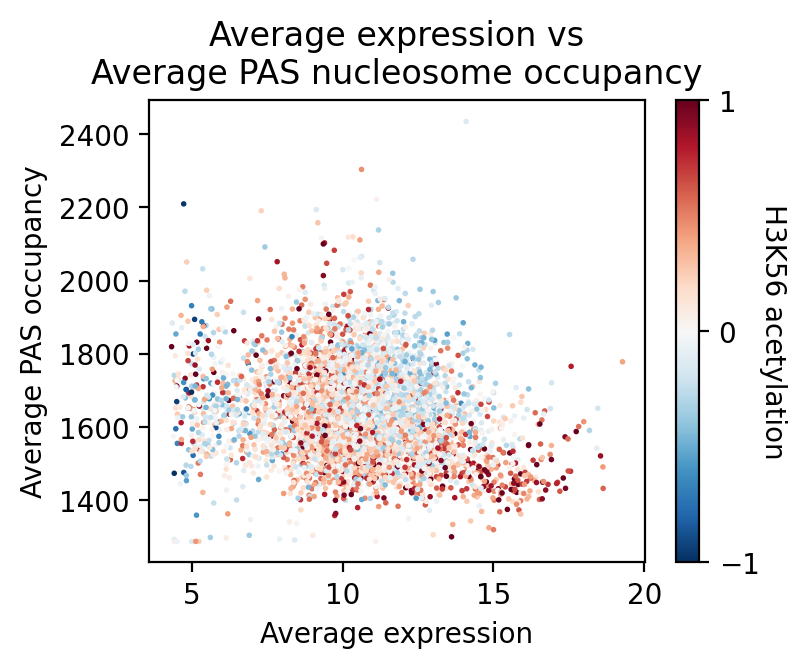

In [54]:
expression_mean = gene_clustering.gene_expression[t_indices].mean(axis=1)
pas_gb_nuc_occ = all_pas_gb_nuc_occ[t_indices].mean(axis=1)

compare_acetyl_tx = genes_h3k56ac.copy()
compare_acetyl_tx['mean_expression'] = expression_mean
compare_acetyl_tx['mean_pas_gene_body_occupancy'] = pas_gb_nuc_occ

plt.figure(figsize=(4, 3))

plt.scatter(compare_acetyl_tx.mean_expression, 
            compare_acetyl_tx.mean_pas_gene_body_occupancy, s=1,
           c=compare_acetyl_tx.mean_acetylation, alpha=1,
           vmin=-1, vmax=1, cmap='RdBu_r')
plt.ylabel("Average PAS occupancy")
plt.xlabel("Average expression")
cbar = plt.colorbar()
cbar.ax.set_ylabel("H3K56 acetylation", rotation=270, va='bottom', labelpad=0)
cbar.ax.set_yticks([-1, 0, 1])
plt.title("Average expression vs\nAverage PAS nucleosome occupancy")

# On average most highly expressed genes show lower PAS occupancy and
# are higher in H3K56 acetylation

# Lower expressed genes tend to be lower in H3K56 acetylation

# Interestingly: higher expressed genes may be subject to buffering
# Are the lower expressed genes more subject to buffering?
#    Do the nucleosome occupancy values reflect buffering changes?

In [206]:
mean_entropy = all_pas_gb_nuc_entropy.mean(axis=1)

In [381]:
# Two options for computing gene expression correlation:
# 1. Raw data: Each replicate has an expression curve that can be correlated
#    with the mixture + copy number curves
#
# 2. Deconvolved data: Copy number curve will look like a step function at S time
#    No data will look exactly like this, but this is what the replication curve should
#    be estimated to look like. This should be the most "correct" way.

repl_indices = genes_replication.replication_H_index

def modify_matrix_vectorized(vec, width):
    n = len(vec)
    # Create a column index array broadcasted to matrix shape
    col_indices = np.arange(width).reshape(1, -1)
    # Create a row position array from the input vector, shaped for broadcasting
    row_positions = (vec - 1).reshape(-1, 1)
    
    # Create matrix of ones with specified width
    matrix = np.ones((n, width))
    # Set elements to 2 where column index >= row position
    matrix[col_indices >= row_positions] = 2
    
    return matrix

H, hpos = config.calcH_function(config.intervals_wt1, config.WT1_TIMEPOINTS)
genes_replication_mat = modify_matrix_vectorized(repl_indices.astype(int).values, 
    H.shape[1])

genes_repl_mat_df = pd.DataFrame(genes_replication_mat, 
    index=repl_indices.index)


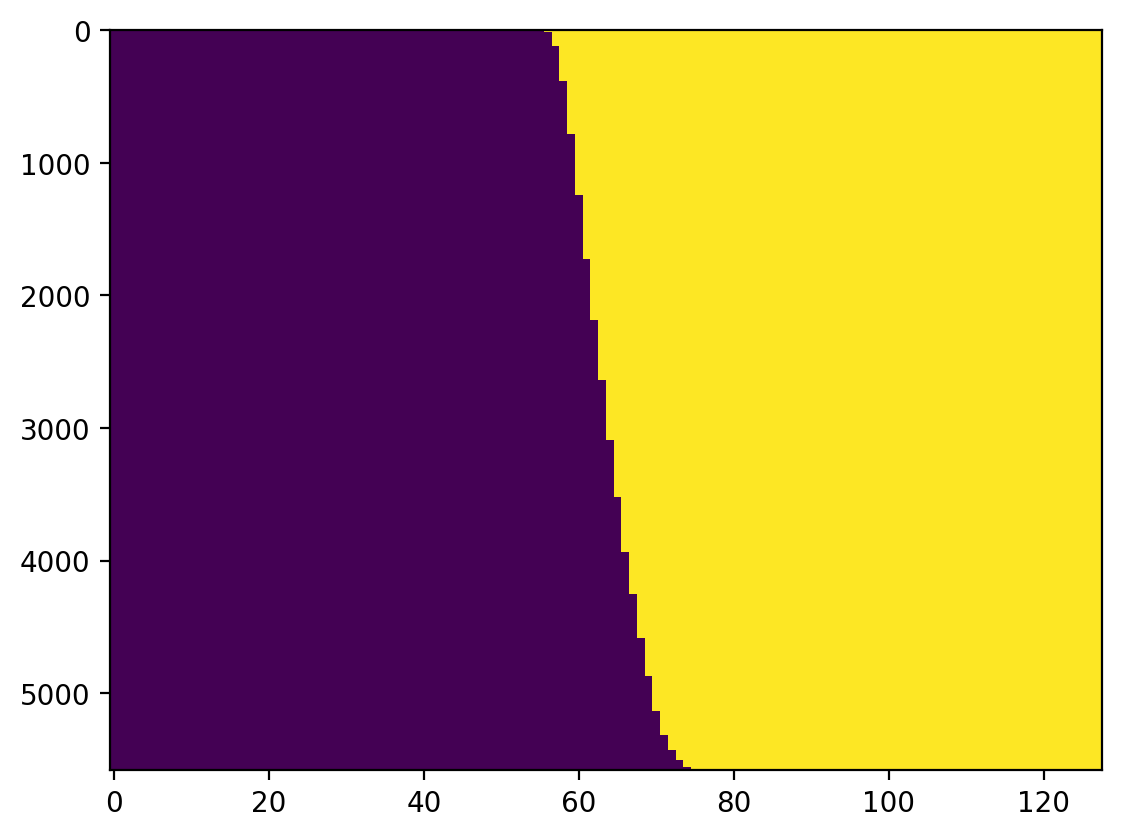

In [385]:
plt.imshow(genes_repl_mat_df[t_indices],
           aspect='auto', interpolation='none')


In [394]:
# Compute the correlation with replication
gene_expression_t = gene_clustering.gene_expression[t_indices]

expression_replication_correlation = gene_expression_t[[]].copy()
expression_replication_correlation['pearson_r'] = np.nan
expression_replication_correlation['pearson_pval'] = np.nan

for orf_name, repl_row in genes_repl_mat_df.iterrows():
    
    replication_vector = repl_row[t_indices]
    gene_expression = gene_expression_t.loc[orf_name]
    
    pearsonr_val, pval = pearsonr(replication_vector, gene_expression)
    expression_replication_correlation.loc[orf_name, 'pearson_r'] = pearsonr_val
    expression_replication_correlation.loc[orf_name, 'pearson_pval'] = pval


In [396]:
expression_replication_correlation.sort_values('pearson_r')

,pearson_r,pearson_pval
orf_name,,
YER170W,-0.914736,1.996025e-51
YJL074C,-0.913573,4.513873e-51
YDR511W,-0.909095,9.435213e-50
YJL172W,-0.907718,2.327457e-49
YJR052W,-0.907606,2.504618e-49
...,...,...
YPR155C,0.912512,9.416205e-51
YJL014W,0.913165,5.994409e-51
YEL053C,0.913664,4.236460e-51


In [399]:
compare_expression_nucleosome_correlation = expression_replication_correlation.join(
    compare_acetyl_tx)
compare_expression_nucleosome_correlation = compare_expression_nucleosome_correlation\
    .sort_values('pearson_r').dropna()

In [402]:
compare_expression_nucleosome_correlation

,pearson_r,pearson_pval,mean_acetylation,chr,strand,TSS,PAS,mean_expression,mean_pas_gene_body_occupancy,mean_entropy
orf_name,,,,,,,,,,
YER170W,-0.914736,1.996025e-51,0.592857,5.0,+,525895.0,526996.0,8.704859,1653.16259,9.973142
YJL074C,-0.913573,4.513873e-51,-0.077647,10.0,-,302873.0,299072.0,11.811562,1653.805988,10.117167
YDR511W,-0.909095,9.435213e-50,0.660000,4.0,+,1470033.0,1470502.0,9.494776,1785.307028,9.890258
YJL172W,-0.907718,2.327457e-49,0.394167,10.0,+,97699.0,99609.0,12.645936,1581.570649,10.158159
YJR052W,-0.907606,2.504618e-49,-0.070833,10.0,+,532050.0,533815.0,9.595274,1815.763081,9.926428
...,...,...,...,...,...,...,...,...,...,...
YPR155C,0.912512,9.416205e-51,-0.058000,16.0,-,837480.0,835439.0,10.081109,1786.672352,10.023933
YJL014W,0.913165,5.994409e-51,-0.267500,10.0,+,407497.0,409284.0,13.547895,1578.256974,10.147155
YEL053C,0.913664,4.236460e-51,0.098333,5.0,-,56149.0,53819.0,11.516916,1709.755914,10.05468


Text(0.5, 1.0, 'Expression/Replication\ncorrelation and acetylation')

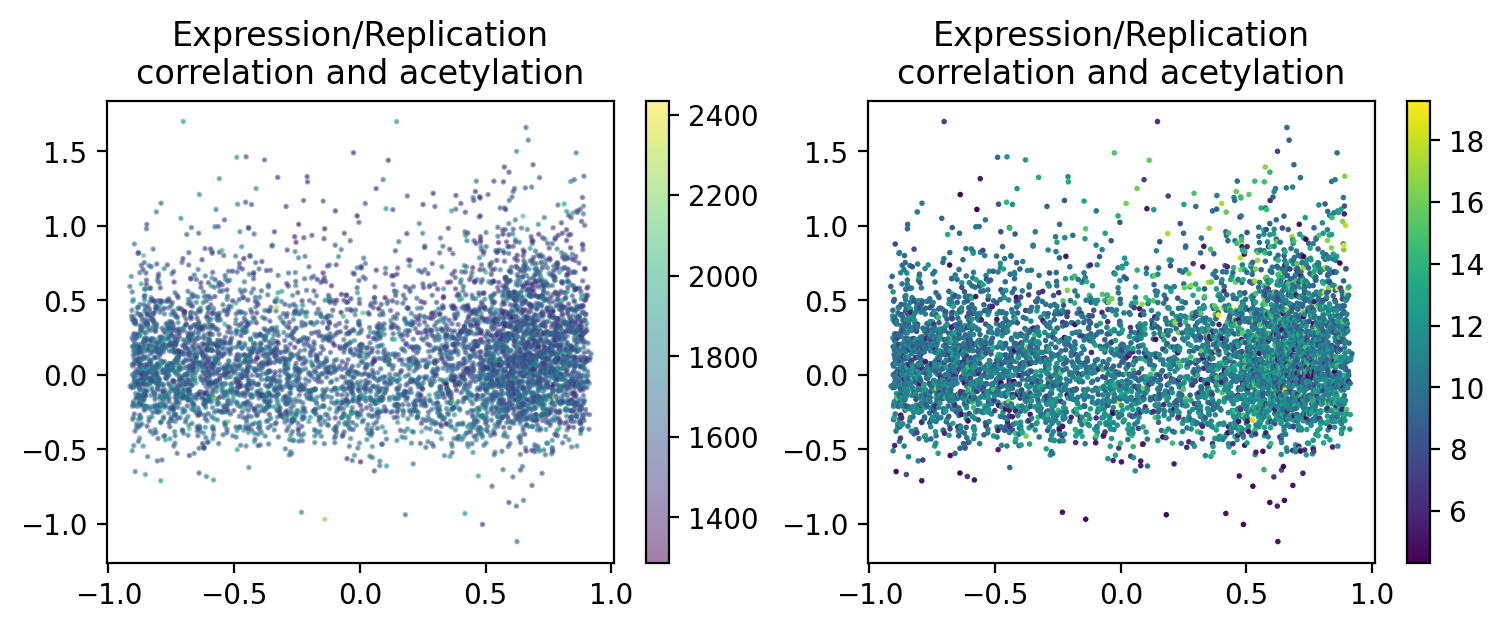

In [403]:
plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.scatter(compare_expression_nucleosome_correlation.pearson_r, 
            compare_expression_nucleosome_correlation.mean_acetylation, 
            c=compare_expression_nucleosome_correlation.mean_pas_gene_body_occupancy, 
            s=1, alpha=0.5)
plt.colorbar()
plt.title("Expression/Replication\ncorrelation and acetylation")

plt.subplot(1, 2, 2)
plt.scatter(compare_expression_nucleosome_correlation.pearson_r, 
            compare_expression_nucleosome_correlation.mean_acetylation, 
            c=compare_expression_nucleosome_correlation.mean_expression, 
            s=1)
plt.colorbar()
plt.title("Expression/Replication\ncorrelation and acetylation")

In [405]:
high_correlation = compare_expression_nucleosome_correlation.tail(400)
low_correlation = compare_expression_nucleosome_correlation.head(400)

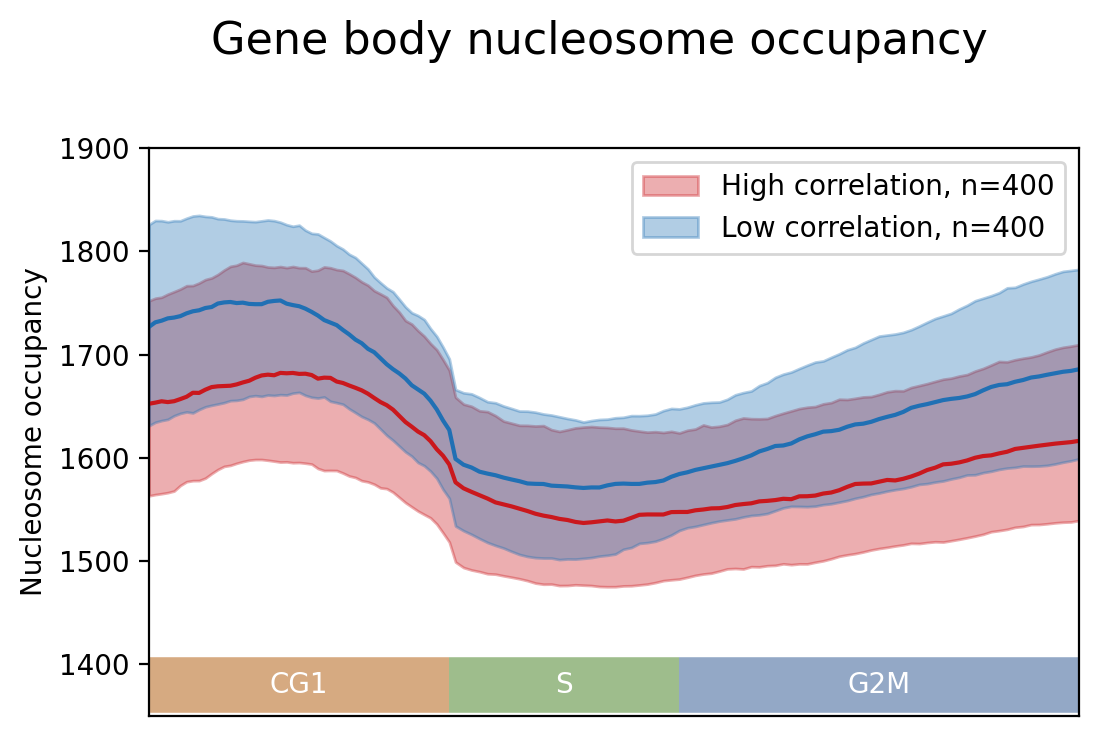

In [406]:
plot_chromatin_timecourse(all_pas_gb_nuc_occ, high_correlation, low_correlation,
    'Gene body nucleosome occupancy', labels=['Low correlation', 'High correlation'],
                         ylim=(1350, 1900), annotations_offset=30)
save_figure_for_paper("output/figures/Buffering/Nucleosome_Occupancy_Buffering.png")

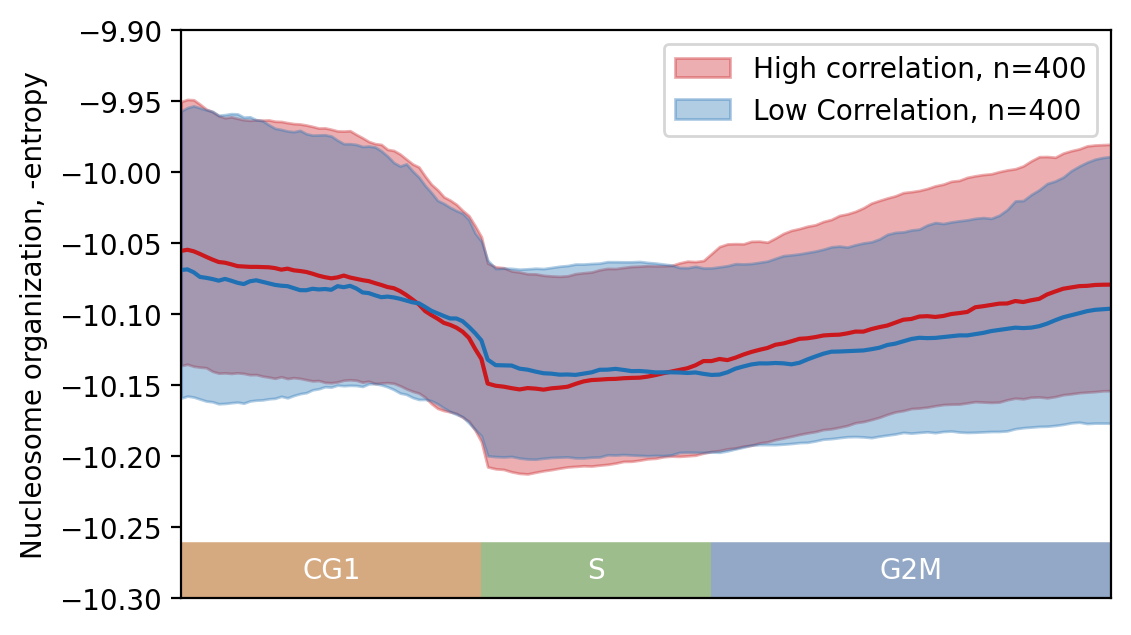

In [235]:
# Not much to show about the chromatin occupancy wise, but this clearly 
# shows the two opposite gene expression profiles

plot_chromatin_timecourse(-all_pas_gb_nuc_entropy, high_correlation, low_correlation,
                      title="", ylim=(-10.3, -9.9), 
                          annotations_offset=0.02,
                          labels=["Low Correlation", "High correlation"],
                         ylabel="Nucleosome organization, -entropy")
save_figure_for_paper("output/figures/Buffering/Nucleosome_Organization_Buffering.png")

In [158]:
entropy_compare_df.head()

,entropy_s,entropy_g2m,mean_acetylation,chr,strand,TSS,PAS
orf_name,,,,,,,
YDR006C,10.073498,10.078981,-0.381333,4.0,-,461399.0,458456.0
YEL044W,10.157041,10.097186,1.490000,5.0,+,69741.0,70309.0
YMR137C,9.772592,9.797815,-0.195000,13.0,-,545025.0,542852.0
YKR027W,10.211587,10.107326,-0.032000,11.0,+,491304.0,493743.0
YER168C,10.171521,10.083798,-0.004000,5.0,-,522696.0,520973.0


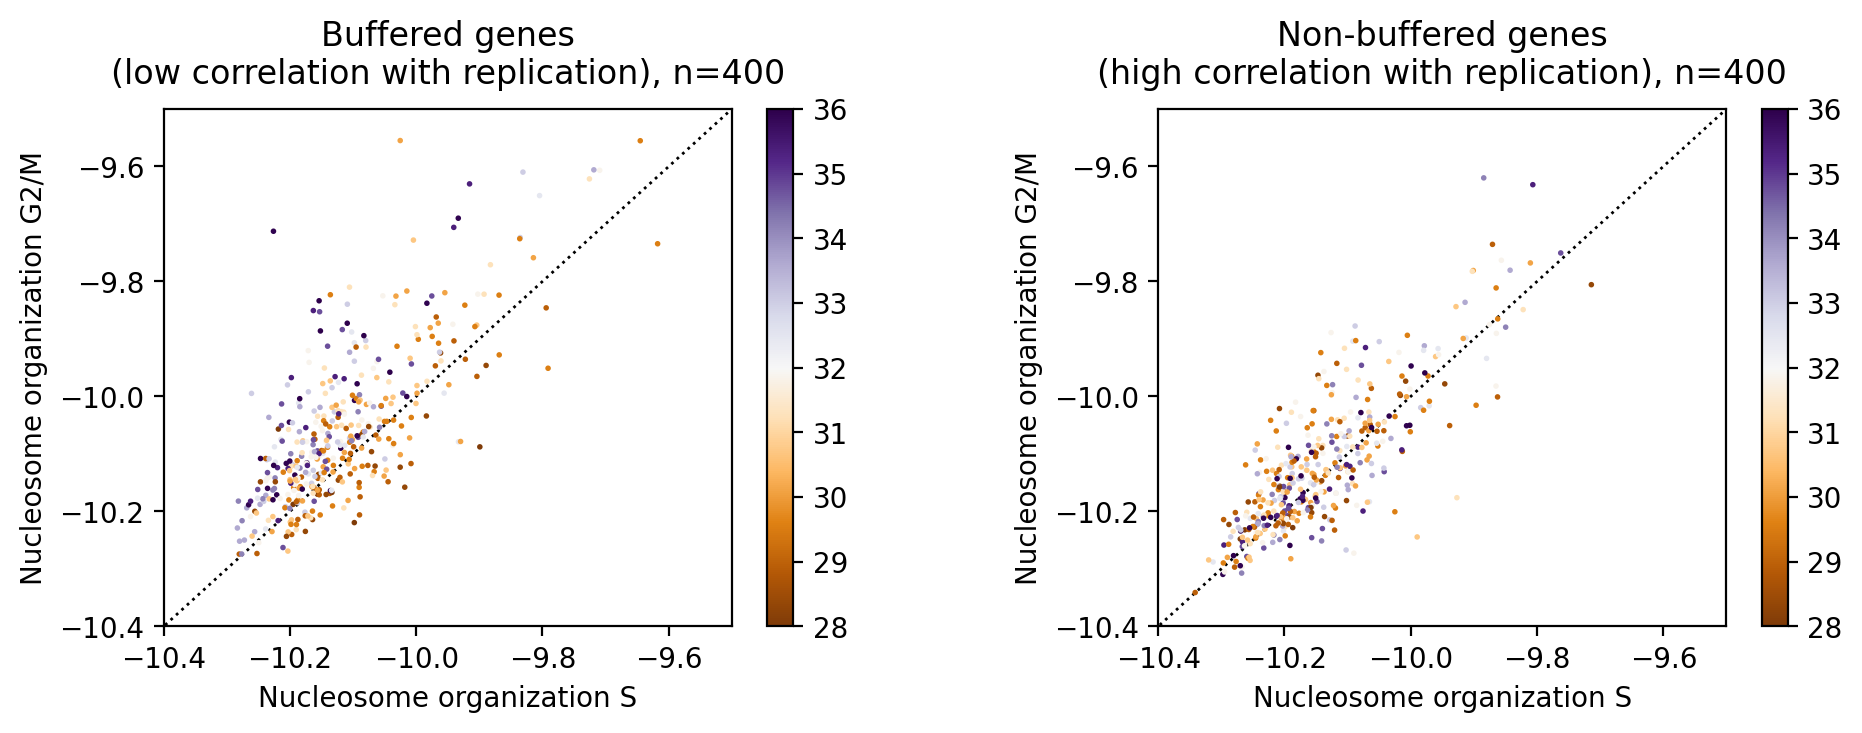

In [457]:
# Scatter plot of entropy for S vs G2M
from src.figure_configs import FiguresConfig

entropy_s_start = all_pas_gb_nuc_entropy[s_g2m_indices[10]]
entropy_g2m_end = all_pas_gb_nuc_entropy[s_g2m_indices[-10]]

entropy_compare_df = pd.DataFrame({'entropy_s': entropy_s_start, 
                                   'entropy_g2m': entropy_g2m_end})
entropy_compare_df = entropy_compare_df.join(genes_h3k56ac)
entropy_compare_df = entropy_compare_df.join(genes_replication)

plt.figure(figsize=(11, 3.75))

cg1_len = config.get_g1_lens('CG1')

low_data = entropy_compare_df.loc[low_correlation.index]
high_data = entropy_compare_df.loc[high_correlation.index]

plt.subplot(1, 2, 1)
plt.scatter(-low_data.entropy_s, -low_data.entropy_g2m, 
            s=1, c=low_data.replication_time+cg1_len, 
            cmap='PuOr', vmin=28, vmax=36)
plt.plot([-100, 0], [-100, 0], zorder=0, lw=1, c='black', ls='dotted')
plt.xlim(-10.4, -9.5)
plt.ylim(-10.4, -9.5)
plt.colorbar()
plt.title(f"Buffered genes\n(low correlation with replication), n={len(high_data)}",
         pad=9)
plt.xlabel("Nucleosome organization S")
plt.ylabel("Nucleosome organization G2/M")

plt.subplot(1, 2, 2)
plt.scatter(-high_data.entropy_s, -high_data.entropy_g2m, 
            s=1, c=low_data.replication_time+cg1_len, vmin=28, vmax=36, cmap='PuOr')
plt.plot([-100, 0], [-100, 0], zorder=0, lw=1, c='black', ls='dotted')
plt.xlim(-10.4, -9.5)
plt.ylim(-10.4, -9.5)
plt.title(f"Non-buffered genes\n(high correlation with replication), n={len(high_data)}",
         pad=9)
plt.xlabel("Nucleosome organization S")
plt.ylabel("Nucleosome organization G2/M")
plt.colorbar()

plt.subplots_adjust(wspace=0.4, top=0.8)


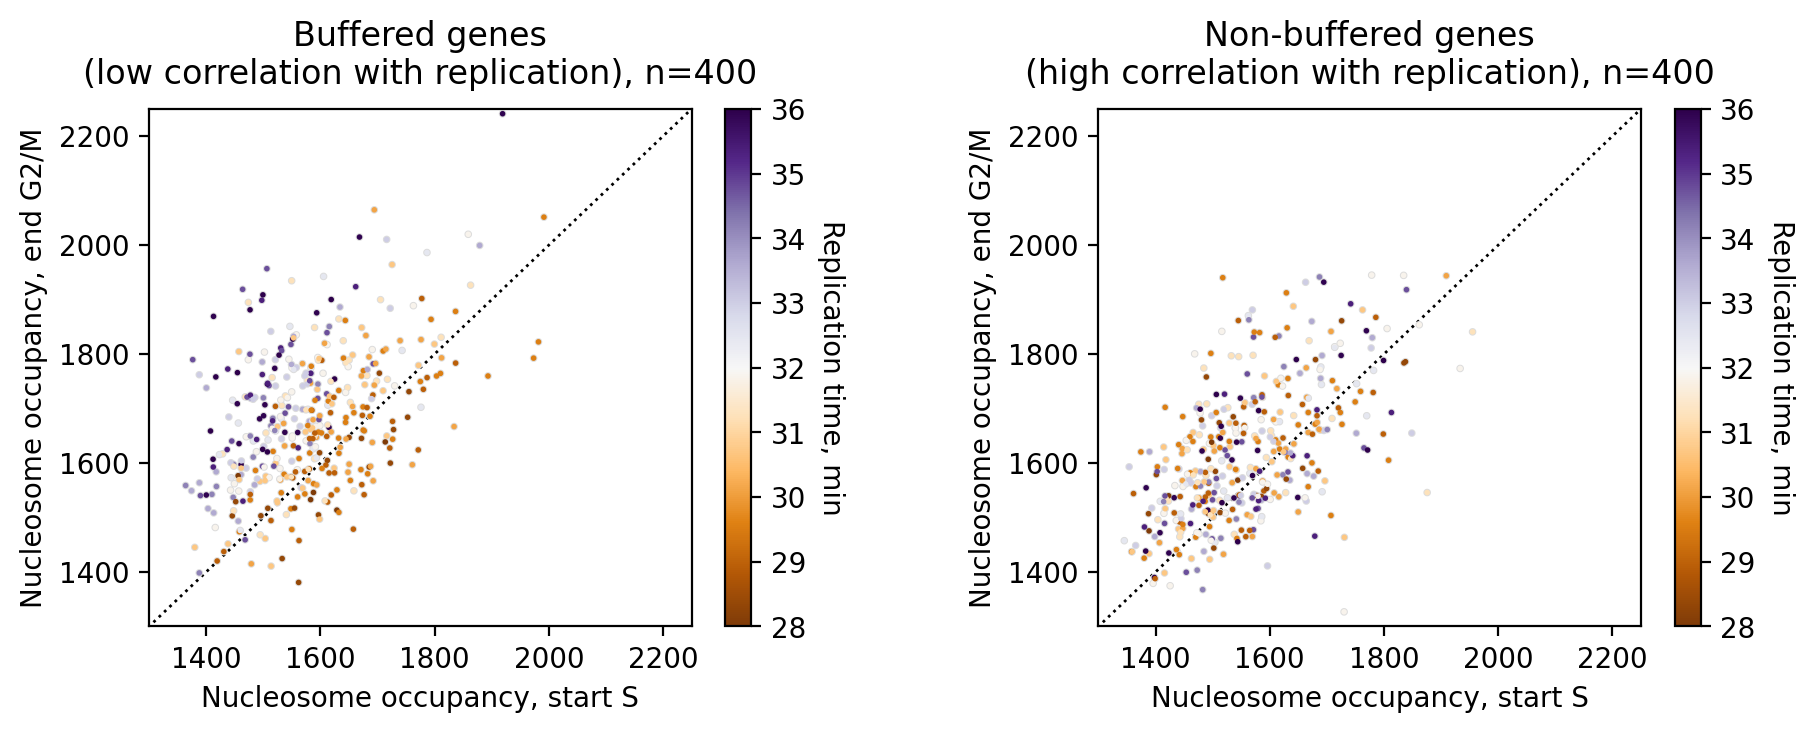

In [456]:
# Scatter plot of entropy for S vs G2M
from src.figure_configs import FiguresConfig

cg1_len = config.get_g1_lens('CG1')
occ_s_start = all_pas_gb_nuc_occ[s_g2m_indices[10]]
occ_g2m_end = all_pas_gb_nuc_occ[s_g2m_indices[-10]]

occ_compare_df = pd.DataFrame({'entropy_s': occ_s_start, 
                                   'entropy_g2m': occ_g2m_end})
occ_compare_df = occ_compare_df.join(genes_h3k56ac)
occ_compare_df = occ_compare_df.join(genes_replication)

plt.figure(figsize=(10.5, 3.75))

low_data = occ_compare_df.loc[low_correlation.index]
high_data = occ_compare_df.loc[high_correlation.index]

plt.subplot(1, 2, 1)
plt.scatter(low_data.entropy_s, low_data.entropy_g2m, 
            s=3, edgecolor='#dddddd', facecolor='none')
plt.scatter(low_data.entropy_s, low_data.entropy_g2m, 
            s=1, c=low_data.replication_time+cg1_len, vmin=28, vmax=36,
            cmap='PuOr')
plt.plot([0, 3000], [0, 3000], zorder=0, lw=1, c='black', ls='dotted')
plt.xlim(1300, 2250)
plt.ylim(1300, 2250)
cbar = plt.colorbar()
cbar.ax.set_ylabel("Replication time, min", rotation=270, va='bottom')
plt.title(f"Buffered genes\n(low correlation with replication), n={len(low_data)}",
    pad=9)
plt.xlabel("Nucleosome occupancy, start S")
plt.ylabel("Nucleosome occupancy, end G2/M")

plt.subplot(1, 2, 2)
plt.scatter(high_data.entropy_s, high_data.entropy_g2m, 
            s=3, edgecolor='#dddddd', facecolor='none')
plt.scatter(high_data.entropy_s, high_data.entropy_g2m, 
            s=1, c=low_data.replication_time+cg1_len, vmin=28, vmax=36,
cmap='PuOr')
plt.plot([0, 3000], [0, 3000], zorder=0, lw=1, c='black', ls='dotted')
plt.xlim(1300, 2250)
plt.ylim(1300, 2250)
plt.title(f"Non-buffered genes\n(high correlation with replication), n={len(high_data)}",
         pad=9)
plt.xlabel("Nucleosome occupancy, start S")
plt.ylabel("Nucleosome occupancy, end G2/M")
cbar = plt.colorbar()
cbar.ax.set_ylabel("Replication time, min", rotation=270, va='bottom')

plt.subplots_adjust(wspace=0.4, top=0.8)
save_figure_for_paper("output/figures/Buffering/Low_High_Correlation_Occupancy_Scatter.png")

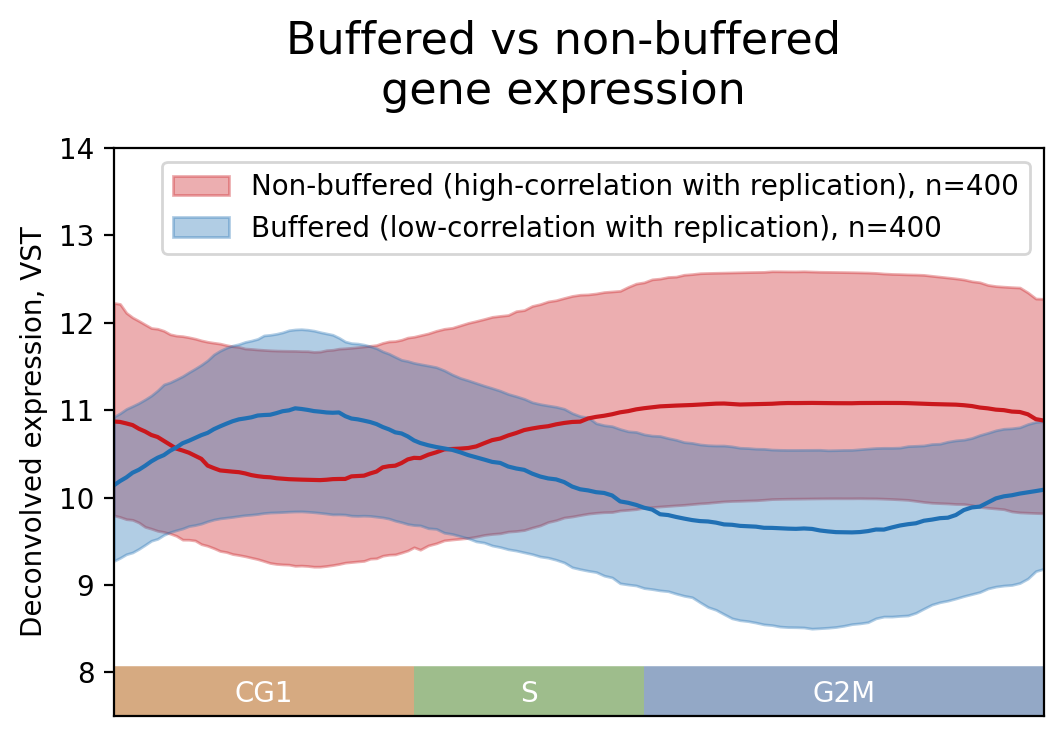

In [460]:
# Not much to show about the chromatin occupancy wise, but this clearly 
# shows the two opposite gene expression profiles

plot_expression_timecourse(gene_clustering, high_correlation, low_correlation,
    'Buffered vs non-buffered\ngene expression', (7.5, 14),
                          labels=[
                              'Buffered (low-correlation with replication)',
                              'Non-buffered (high-correlation with replication)'
                          ])
save_figure_for_paper("output/figures/Buffering/Buffering_Expression.png")

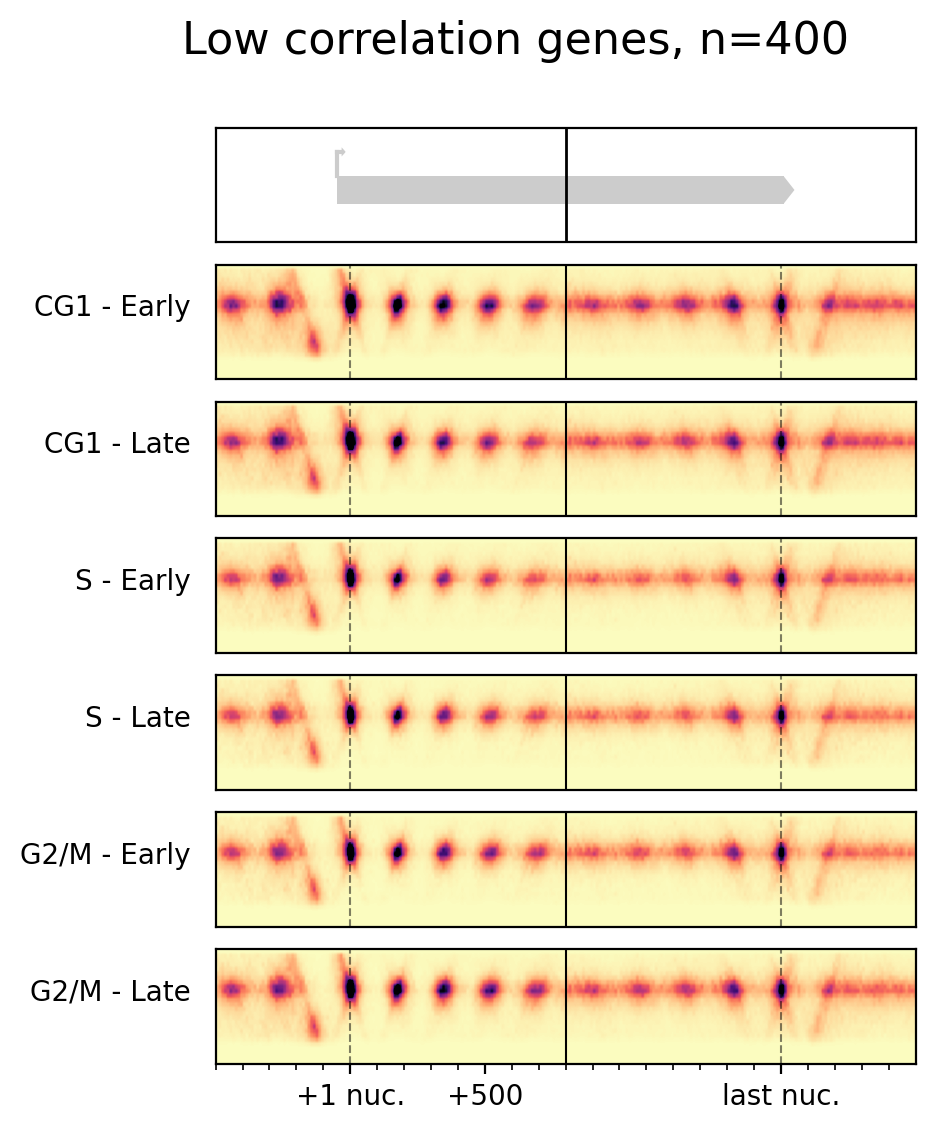

In [408]:
fig = analysis.plot_tss_pas_chrom(low_correlation, 
    title=f"Low correlation genes, n={len(low_correlation)}")
save_figure_for_paper("output/figures/Buffering/Low_Correlation_Chromatin.png")

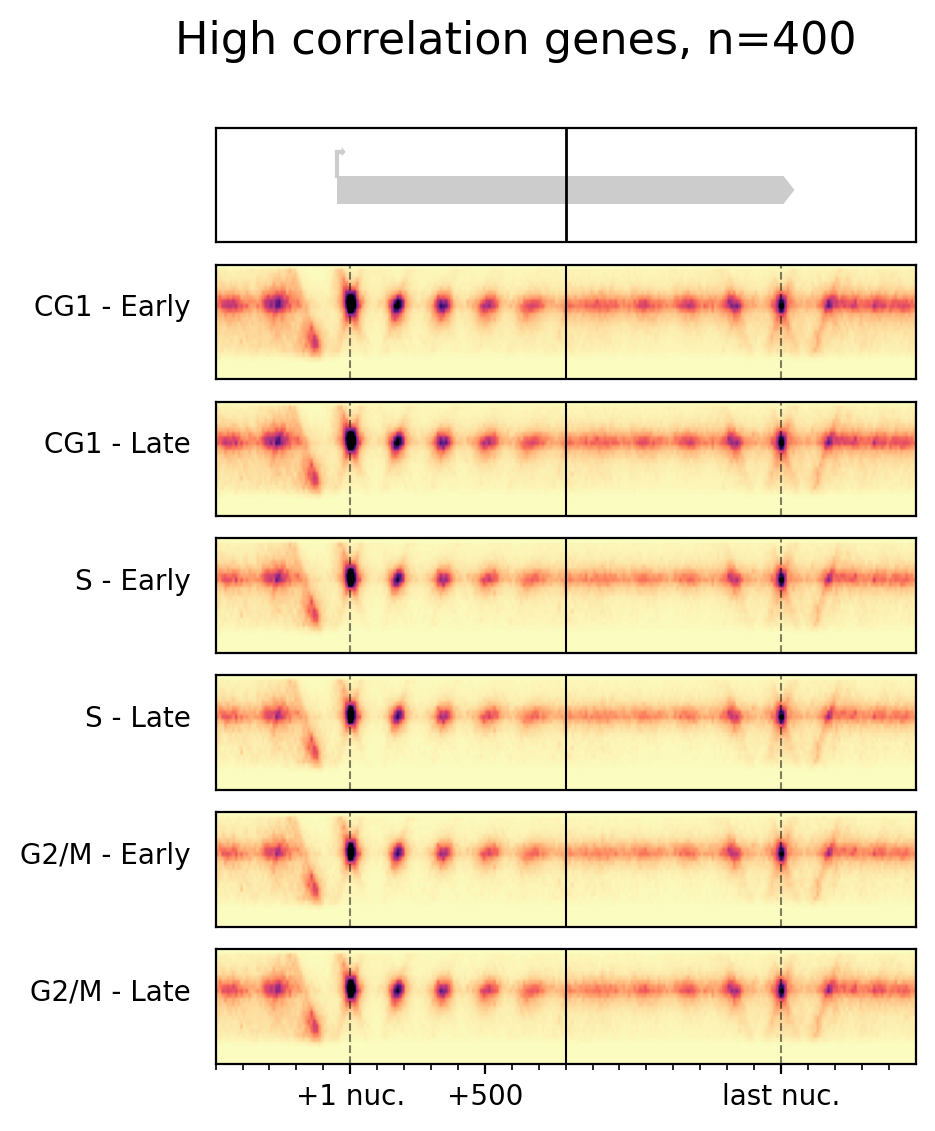

In [409]:
fig = analysis.plot_tss_pas_chrom(high_correlation, 
    title=f"High correlation genes, n={len(high_correlation)}")
save_figure_for_paper("output/figures/Buffering/High_Correlation_Chromatin.png")

In [434]:
# Show that late replicating buffered genes show the greatest
# chromatin changes

compare_replication_timing = occ_compare_df.join(
    expression_replication_correlation[['pearson_r']], how='left').sort_values('pearson_r').dropna()

late_genes = compare_replication_timing[
    (compare_replication_timing.replication_time + cg1_len) > 34]
low_correlation_late_genes = late_genes.head(200)

early_genes = compare_replication_timing[
    (compare_replication_timing.replication_time + cg1_len) < 31]
low_correlation_early_genes = early_genes.head(200)


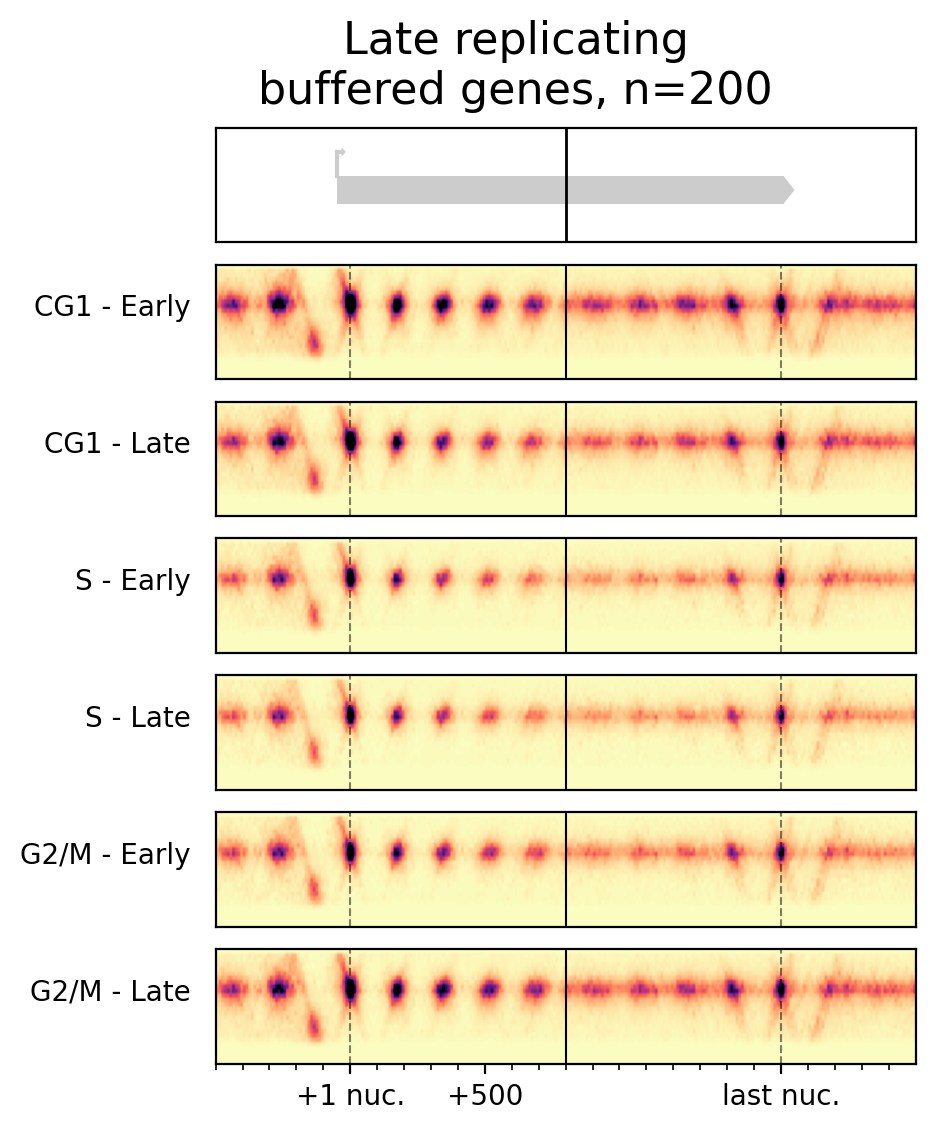

In [462]:
fig = analysis.plot_tss_pas_chrom(low_correlation_late_genes, 
    title=f"Late replicating\nbuffered genes, n={len(low_correlation_late_genes)}")
save_figure_for_paper("output/figures/Buffering/Buffered_Late_Replicating_Chromatin.png")


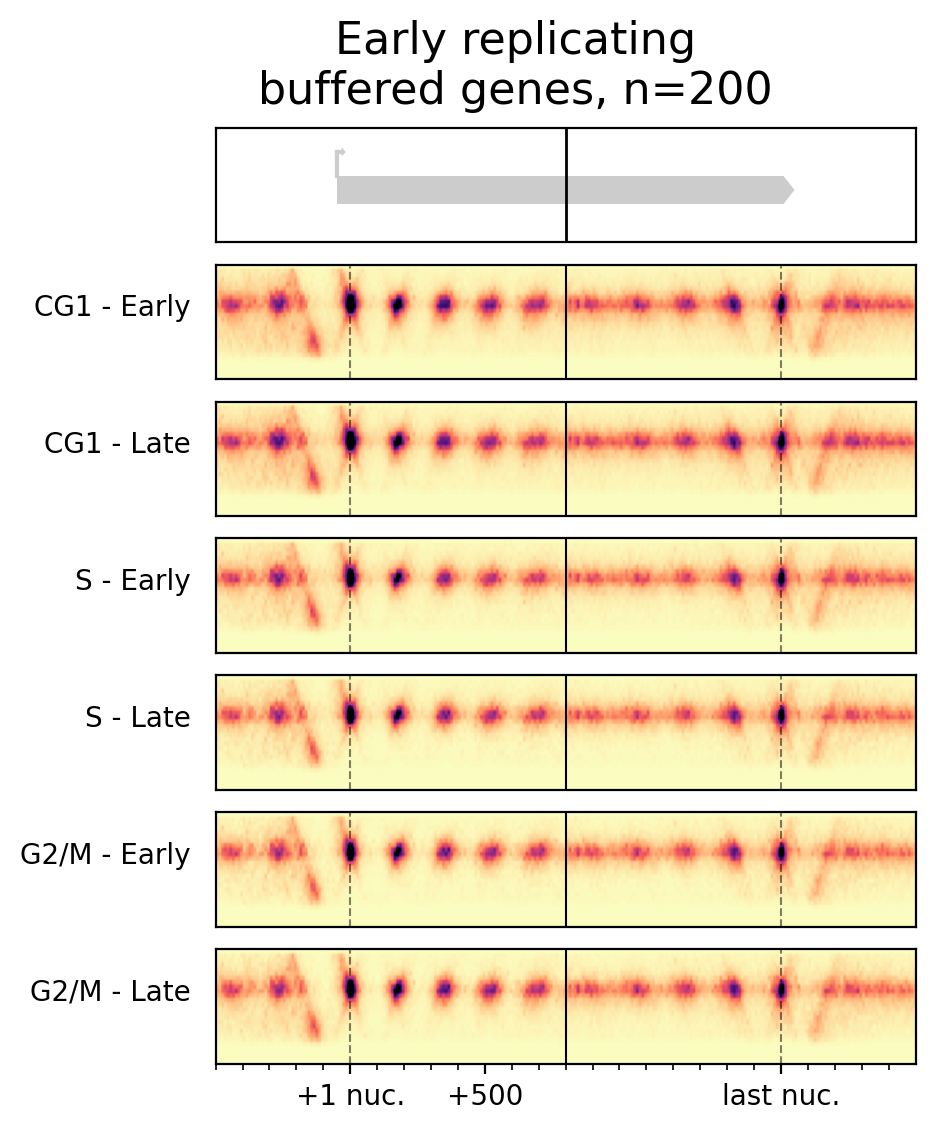

In [461]:
fig = analysis.plot_tss_pas_chrom(low_correlation_early_genes, 
    title=f"Early replicating\nbuffered genes, n={len(low_correlation_early_genes)}")
save_figure_for_paper("output/figures/Buffering/Buffered_Early_Replicating_Chromatin.png")


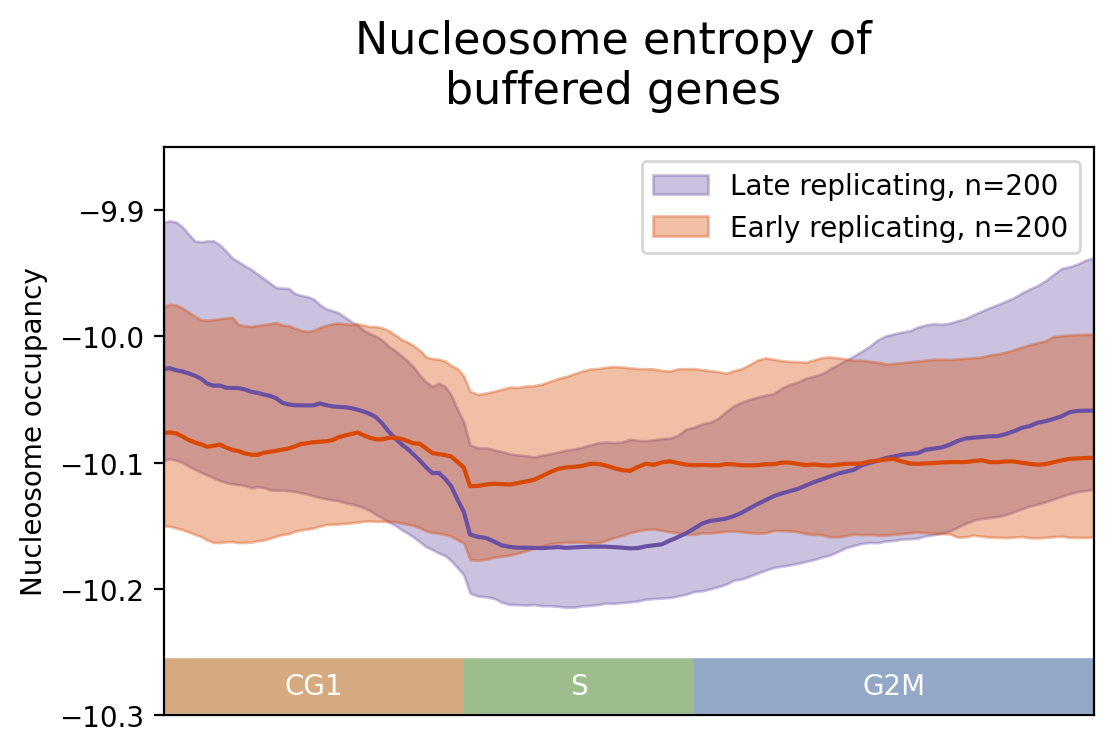

In [474]:
plot_chromatin_timecourse(-all_pas_gb_nuc_entropy, low_correlation_late_genes, low_correlation_early_genes,
                      title= 'Nucleosome entropy of\nbuffered genes', ylim=(-10.3, -9.85), 
                          labels=['Early replicating', 'Late replicating'],
                        annotations_offset=0.023,
                         low_color=plt.get_cmap('Oranges')(0.75),
                         high_color=plt.get_cmap('Purples')(0.75))

save_figure_for_paper("output/figures/Buffering/Nucleosome_Entropy_Buffering_Timecourse.png")

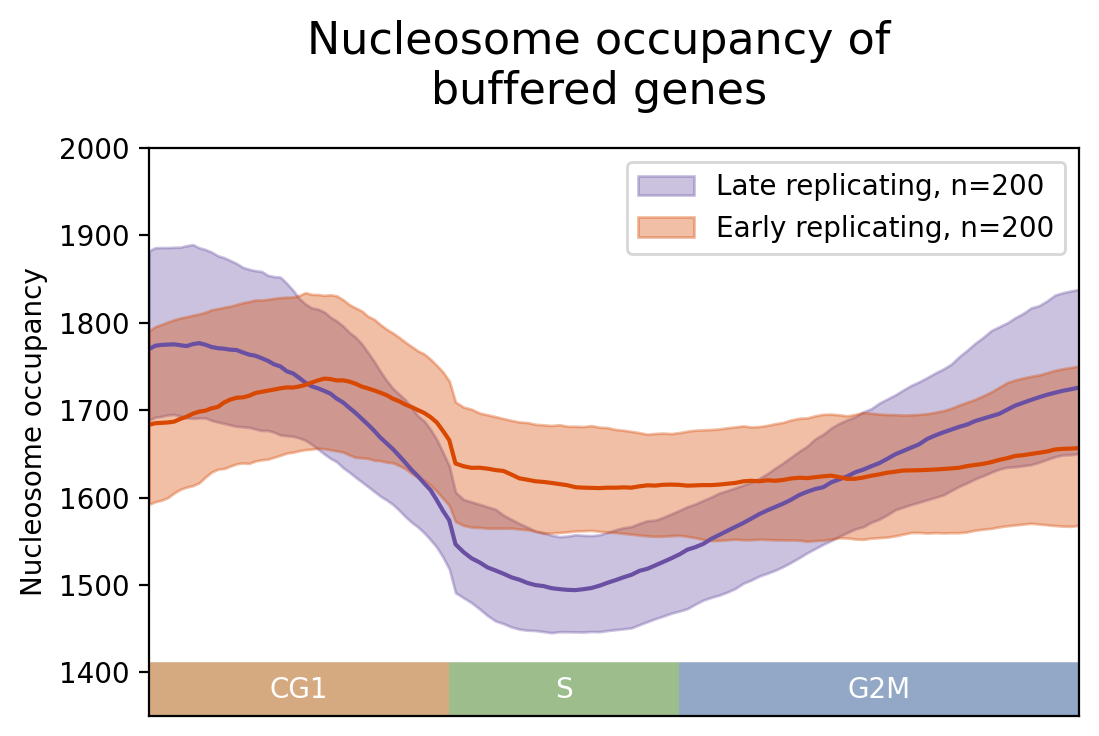

In [475]:
plot_chromatin_timecourse(all_pas_gb_nuc_occ, 
    low_correlation_late_genes, low_correlation_early_genes,
    'Nucleosome occupancy of\nbuffered genes', labels=['Early replicating', 'Late replicating'],
                         ylim=(1350, 2000), annotations_offset=30,
                         low_color=plt.get_cmap('Oranges')(0.75),
                         high_color=plt.get_cmap('Purples')(0.75))
save_figure_for_paper("output/figures/Buffering/Nucleosome_Occupancy_Buffering_Timecourse.png")

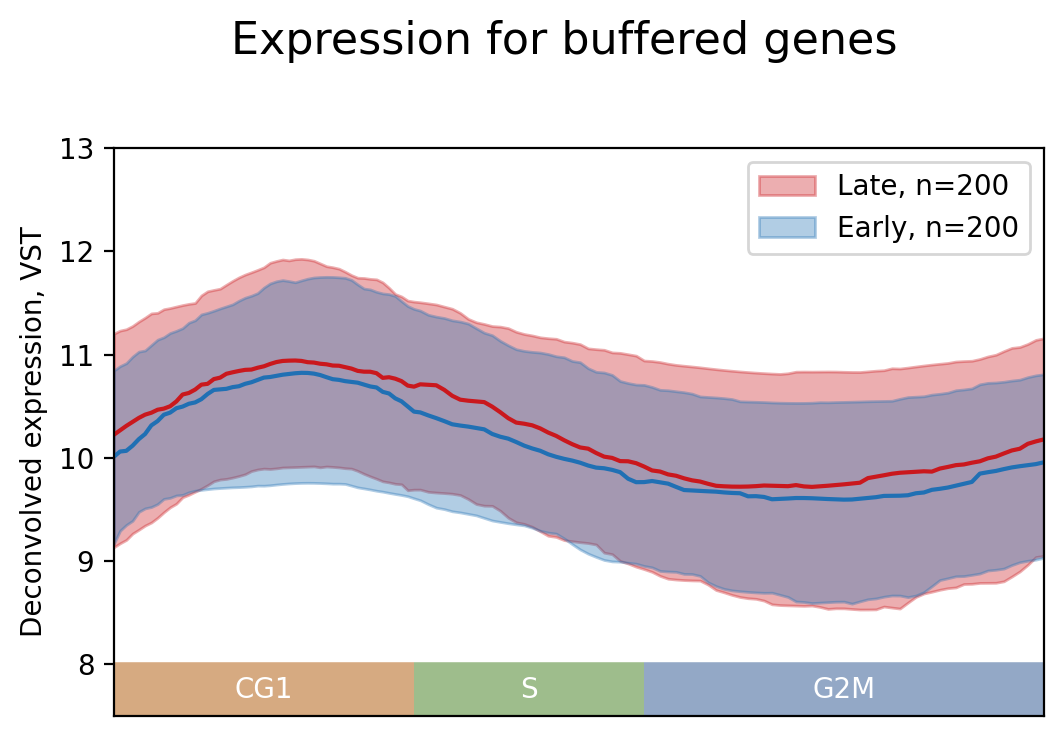

In [445]:
plot_expression_timecourse(gene_clustering, low_correlation_late_genes, 
    low_correlation_early_genes,
    'Expression for buffered genes', (7.5, 13),
                          labels=[
                              'Early',
                              'Late'
                          ])
save_figure_for_paper("output/figures/Buffering/Expression_Buffering_Timecourse.png")
